# DDXPlus — Continuation Notebook
### CS4082 · Topic 5: Automated Medical Diagnosis with Data Poisoning



---
**Notebook Structure:**
- Phase 2 · EDA
- Phase 2 · Data Poisoning Injection
- Phase 3 · Baseline Classifiers
- Phase 3 · 5-Fold CV + ROC Curves + metrics
- Phase 4 · Hyperparameter Tuning
- Phase 4 · Feature Selection
- Phase 4 · Final Ensemble
- Phase 5 · Poisoning Experiment (Main Result)
- Phase 5 · Final Test Set Evaluation
- Phase 5 · Limitations Analysis

## 0. Load the Dataset and Preprocess

After the preprocessing, we save using joblib to Drive so we can reload the variables in 2 seconds instead of rerunning hours of computation over and over.

In [ ]:
# =========================
# LOAD + PREPROCESS
# =========================
import numpy as np
import pandas as pd
import ast
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder, StandardScaler
from scipy.sparse import hstack, save_npz, load_npz
import joblib

np.random.seed(42)

# LOAD DATA
df_train = pd.read_csv("/content/drive/MyDrive/ML_project/release_train_patients.csv")
df_val   = pd.read_csv("/content/drive/MyDrive/ML_project/release_validate_patients.csv")
df_test  = pd.read_csv("/content/drive/MyDrive/ML_project/release_test_patients.csv")

# HANDLE MISSING
def handle_missing(df):
    df['AGE'] = df['AGE'].fillna(df['AGE'].median())
    df['SEX'] = df['SEX'].fillna(df['SEX'].mode()[0])
    df['EVIDENCES'] = df['EVIDENCES'].fillna("[]")
    return df

df_train = handle_missing(df_train)
df_val   = handle_missing(df_val)
df_test  = handle_missing(df_test)

# PARSE LISTS
for df in [df_train, df_val, df_test]:
    df['EVIDENCES'] = df['EVIDENCES'].apply(ast.literal_eval)

# ENCODE SEX
gender_map = {'M': 0, 'F': 1}
for df in [df_train, df_val, df_test]:
    df['SEX_ENC'] = df['SEX'].map(gender_map)

# ENCODE INITIAL EVIDENCE
le_init = LabelEncoder()
df_train['INIT_ENC'] = le_init.fit_transform(df_train['INITIAL_EVIDENCE'])

def safe_transform(le, x):
    return le.transform([x])[0] if x in le.classes_ else -1

df_val['INIT_ENC'] = df_val['INITIAL_EVIDENCE'].apply(lambda x: safe_transform(le_init, x))
df_test['INIT_ENC'] = df_test['INITIAL_EVIDENCE'].apply(lambda x: safe_transform(le_init, x))

# MULTI-LABEL EVIDENCE
mlb = MultiLabelBinarizer(sparse_output=True)
X_train_evd = mlb.fit_transform(df_train['EVIDENCES'])
X_val_evd   = mlb.transform(df_val['EVIDENCES'])
X_test_evd  = mlb.transform(df_test['EVIDENCES'])

# LABEL ENCODING
le = LabelEncoder()
y_train = le.fit_transform(df_train['PATHOLOGY'])
y_val   = le.transform(df_val['PATHOLOGY'])
y_test  = le.transform(df_test['PATHOLOGY'])

# SCALE AGE
scaler = StandardScaler()
df_train['AGE_SCALED'] = scaler.fit_transform(df_train[['AGE']])
df_val['AGE_SCALED']   = scaler.transform(df_val[['AGE']])
df_test['AGE_SCALED']  = scaler.transform(df_test[['AGE']])

# FINAL FEATURES
X_train = hstack([df_train[['AGE_SCALED','SEX_ENC','INIT_ENC']].values, X_train_evd])
X_val   = hstack([df_val[['AGE_SCALED','SEX_ENC','INIT_ENC']].values, X_val_evd])
X_test  = hstack([df_test[['AGE_SCALED','SEX_ENC','INIT_ENC']].values, X_test_evd])

X_train = X_train.tocsr()
X_val   = X_val.tocsr()
X_test  = X_test.tocsr()
# =========================
# SAVE EVERYTHING
# =========================
save_npz("/content/drive/MyDrive/ML_project/X_train.npz", X_train)
save_npz("/content/drive/MyDrive/ML_project/X_val.npz", X_val)
save_npz("/content/drive/MyDrive/ML_project/X_test.npz", X_test)

joblib.dump(y_train, "/content/drive/MyDrive/ML_project/y_train.pkl")
joblib.dump(y_val, "/content/drive/MyDrive/ML_project/y_val.pkl")
joblib.dump(y_test, "/content/drive/MyDrive/ML_project/y_test.pkl")
joblib.dump(le, "/content/drive/MyDrive/ML_project/label_encoder.pkl")

print("Preprocessing DONE and SAVED")

---
## 1 · RELOAD EVERYTHING FROM PREVIOUS NOTEBOOK
This cell is for loading everything. Crucial in saving time in cases when the session crashed or runtime ends

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import ast
import warnings
warnings.filterwarnings('ignore')

from scipy.sparse import load_npz
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score

BASE = "/content/drive/MyDrive/ML_project"

X_train = load_npz(f"{BASE}/X_train.npz").tocsr()
X_val   = load_npz(f"{BASE}/X_val.npz").tocsr()
X_test  = load_npz(f"{BASE}/X_test.npz").tocsr()

y_train = joblib.load(f"{BASE}/y_train.pkl")
y_val   = joblib.load(f"{BASE}/y_val.pkl")
y_test  = joblib.load(f"{BASE}/y_test.pkl")
le      = joblib.load(f"{BASE}/label_encoder.pkl")

# Also reload raw DataFrames for EDA
df_train = pd.read_csv(f"{BASE}/release_train_patients.csv")
df_val   = pd.read_csv(f"{BASE}/release_validate_patients.csv")
df_test  = pd.read_csv(f"{BASE}/release_test_patients.csv")

for df in [df_train, df_val, df_test]:
    df['AGE']       = df['AGE'].fillna(df['AGE'].median())
    df['SEX']       = df['SEX'].fillna(df['SEX'].mode()[0])
    df['EVIDENCES'] = df['EVIDENCES'].fillna('[]').apply(ast.literal_eval)

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {len(y_train)}  |  Classes: {len(le.classes_)}")
print("All data loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train: (1025602, 518)  |  X_val: (132448, 518)  |  X_test: (134529, 518)
y_train: 1025602  |  Classes: 49
All data loaded.


---
## PHASE 2 · PART A — Exploratory Data Analysis (EDA)
This section covers class distribution, age/sex demographics, evidence analysis, and missing values.

Missing Values in Training Set:
No missing values found.


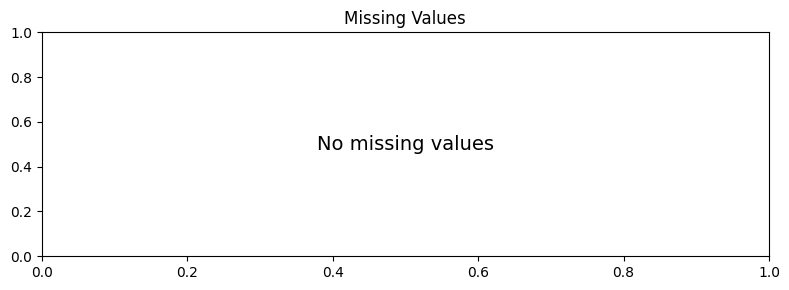

In [ ]:
# ─────────────────────────────────────────────
# EDA 1: MISSING VALUES (on RAW data before filling)
# ─────────────────────────────────────────────
df_raw = pd.read_csv(f"{BASE}/release_train_patients.csv")

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Missing Values in Training Set:")
print(missing_df if not missing_df.empty else "No missing values found.")

fig, ax = plt.subplots(figsize=(8, 3))
if not missing_df.empty:
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='salmon')
    ax.set_title('Missing Values (%) per Feature')
    ax.set_xlabel('Missing %')
else:
    ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=14)
    ax.set_title('Missing Values')
plt.tight_layout()
plt.show()

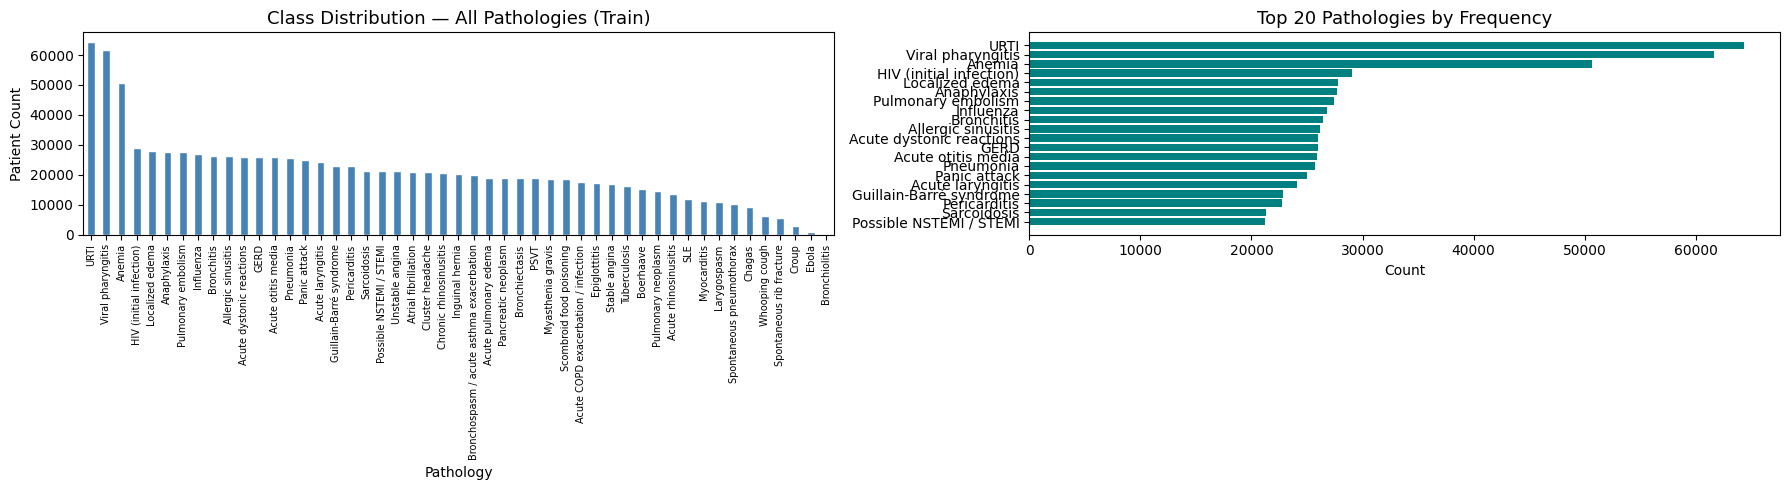

Most common:  URTI  (64,368 samples)
Least common: Bronchiolitis  (261 samples)
Imbalance ratio (max/min): 246.6x


In [ ]:
# ─────────────────────────────────────────────
# EDA 2: CLASS DISTRIBUTION (Pathologies)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Full distribution
counts = df_train['PATHOLOGY'].value_counts()
counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Class Distribution — All Pathologies (Train)', fontsize=13)
axes[0].set_xlabel('Pathology')
axes[0].set_ylabel('Patient Count')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)

# Imbalance ratio
axes[1].barh(counts.index[:20], counts.values[:20], color='teal')
axes[1].set_title('Top 20 Pathologies by Frequency', fontsize=13)
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Most common:  {counts.index[0]}  ({counts.values[0]:,} samples)")
print(f"Least common: {counts.index[-1]}  ({counts.values[-1]:,} samples)")
print(f"Imbalance ratio (max/min): {counts.values[0] / counts.values[-1]:.1f}x")

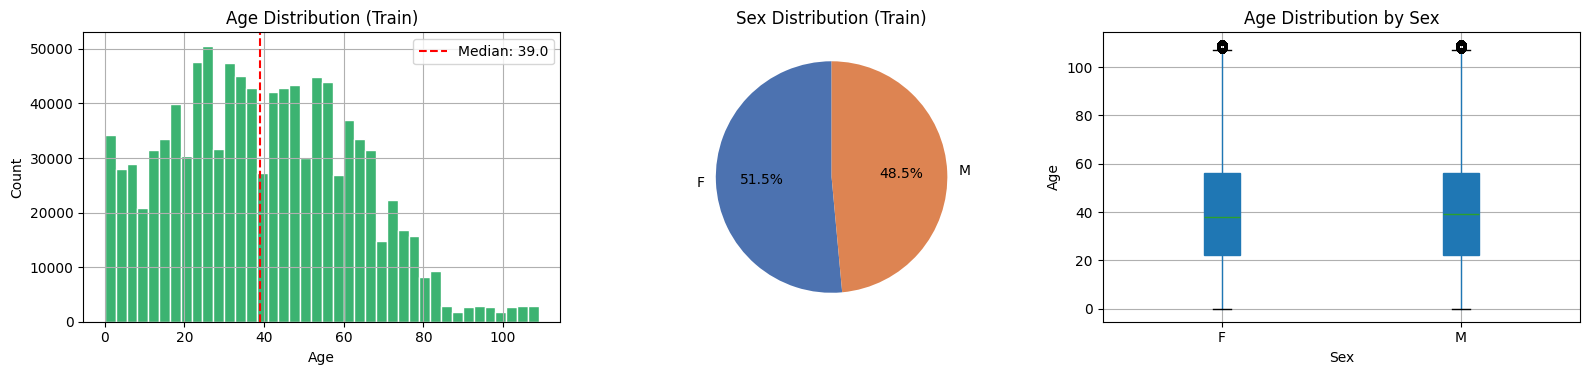

count    1.025602e+06
mean     3.971484e+01
std      2.271728e+01
min      0.000000e+00
25%      2.200000e+01
50%      3.900000e+01
75%      5.600000e+01
max      1.090000e+02
Name: AGE, dtype: float64


In [ ]:
# ─────────────────────────────────────────────
# EDA 3: AGE & SEX DISTRIBUTIONS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age histogram
df_train['AGE'].hist(bins=40, ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Age Distribution (Train)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(df_train['AGE'].median(), color='red', linestyle='--', label=f'Median: {df_train["AGE"].median()}')
axes[0].legend()

# Sex distribution
df_train['SEX'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                     colors=['#4C72B0','#DD8452'], startangle=90)
axes[1].set_title('Sex Distribution (Train)')
axes[1].set_ylabel('')

# Age by sex box plot
df_train.boxplot(column='AGE', by='SEX', ax=axes[2], patch_artist=True)
axes[2].set_title('Age Distribution by Sex')
axes[2].set_xlabel('Sex')
axes[2].set_ylabel('Age')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(df_train['AGE'].describe())

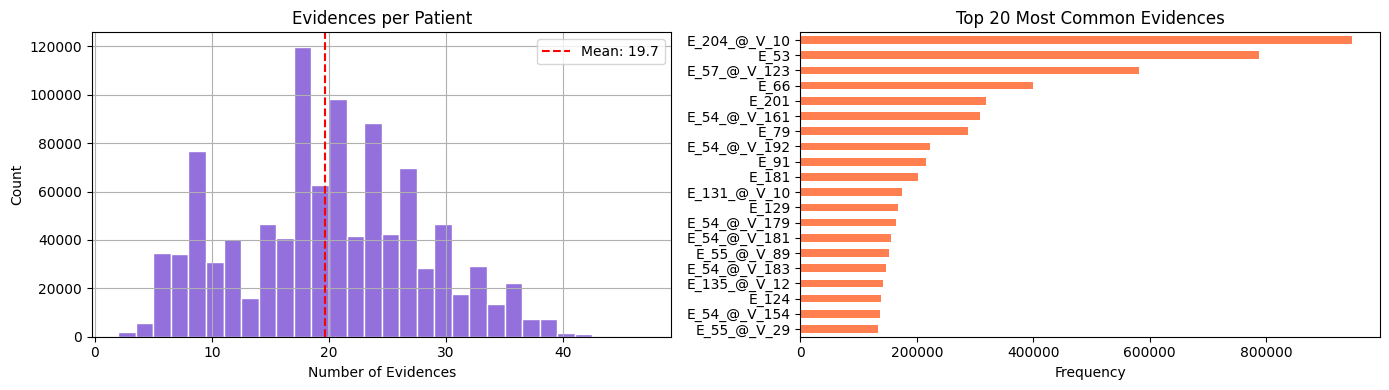

Total unique evidences: 515
Avg evidences per patient: 19.69
Max evidences per patient: 47


In [ ]:
# ─────────────────────────────────────────────
# EDA 4: EVIDENCE ANALYSIS
# ─────────────────────────────────────────────
from collections import Counter

# Evidence count per patient
df_train['EVIDENCE_COUNT'] = df_train['EVIDENCES'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Evidence count distribution
df_train['EVIDENCE_COUNT'].hist(bins=30, ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Evidences per Patient')
axes[0].set_xlabel('Number of Evidences')
axes[0].set_ylabel('Count')
axes[0].axvline(df_train['EVIDENCE_COUNT'].mean(), color='red', linestyle='--',
                label=f'Mean: {df_train["EVIDENCE_COUNT"].mean():.1f}')
axes[0].legend()

# Top 20 most frequent individual evidences
all_evd = [e for evlist in df_train['EVIDENCES'] for e in evlist]
evd_counts = Counter(all_evd)
top20_evd = pd.Series(evd_counts).nlargest(20)
top20_evd.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 20 Most Common Evidences')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Total unique evidences: {len(evd_counts)}")
print(f"Avg evidences per patient: {df_train['EVIDENCE_COUNT'].mean():.2f}")
print(f"Max evidences per patient: {df_train['EVIDENCE_COUNT'].max()}")

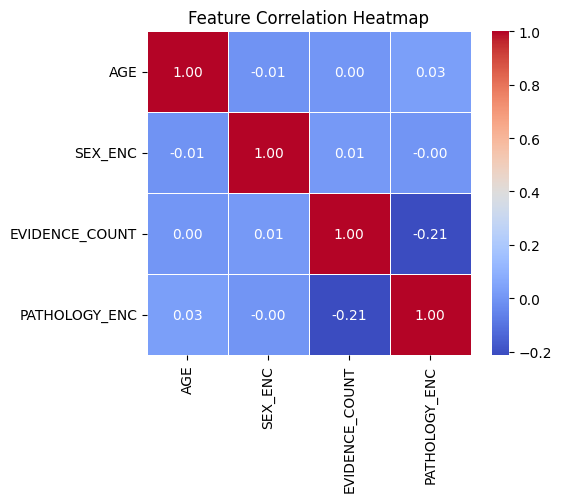

In [ ]:
# ─────────────────────────────────────────────
# EDA 5: FEATURE CORRELATION (numeric features only)
# ─────────────────────────────────────────────
# Encode for correlation
corr_df = df_train[['AGE']].copy()
corr_df['SEX_ENC'] = df_train['SEX'].map({'M': 0, 'F': 1})
corr_df['EVIDENCE_COUNT'] = df_train['EVIDENCE_COUNT']
corr_df['PATHOLOGY_ENC'] = pd.factorize(df_train['PATHOLOGY'])[0]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

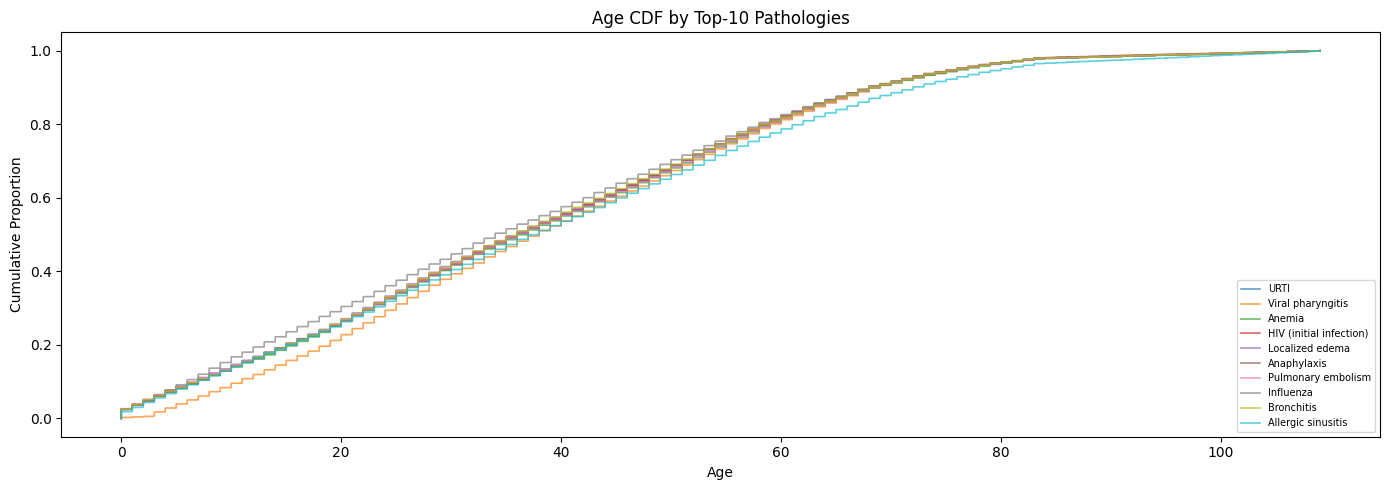

In [ ]:
# ─────────────────────────────────────────────
# EDA 6: AGE DISTRIBUTION BY TOP-10 PATHOLOGIES
# ─────────────────────────────────────────────
top10_pathologies = df_train['PATHOLOGY'].value_counts().index[:10]
df_top10 = df_train[df_train['PATHOLOGY'].isin(top10_pathologies)]

plt.figure(figsize=(14, 5))
for i, path in enumerate(top10_pathologies):
    subset = df_top10[df_top10['PATHOLOGY'] == path]['AGE']
    plt.plot(sorted(subset.values), np.linspace(0, 1, len(subset)),
             label=path, alpha=0.7, linewidth=1.2)

plt.xlabel('Age')
plt.ylabel('Cumulative Proportion')
plt.title('Age CDF by Top-10 Pathologies')
plt.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()

---
## PHASE 2 · PART B — Data Poisoning Injection
**This is the core adversarial condition for Topic 5.**  
We simulate a malicious actor who corrupts a fraction of training labels before the model learns. We test 3 poison rates: 10%, 20%, 30%.

In [ ]:
# ─────────────────────────────────────────────
# DATA POISONING: Label Flipping Attack
# ─────────────────────────────────────────────
def poison_labels(y, poison_rate=0.15, seed=42):
    """
    Simulates a label-flipping data poisoning attack.
    Randomly selects `poison_rate` fraction of training samples
    and reassigns them to a DIFFERENT (wrong) class.

    This mimics a real-world threat where an attacker corrupts
    a medical training database before deployment.
    """
    rng = np.random.default_rng(seed)
    y_poisoned = y.copy()
    n = len(y)
    n_classes = len(np.unique(y))

    n_poison = int(n * poison_rate)
    poison_idx = rng.choice(n, size=n_poison, replace=False)

    for idx in poison_idx:
        original_class = y_poisoned[idx]
        wrong_classes = [c for c in range(n_classes) if c != original_class]
        y_poisoned[idx] = rng.choice(wrong_classes)

    # Verify
    actual_flipped = np.sum(y_poisoned != y)
    print(f"  Poison rate {poison_rate*100:.0f}%: {actual_flipped:,} labels flipped "
          f"({actual_flipped/n*100:.2f}% of {n:,} samples)")
    return y_poisoned


print("Injecting data poisoning at three rates...")
y_train_p10 = poison_labels(y_train, poison_rate=0.10)
y_train_p20 = poison_labels(y_train, poison_rate=0.20)
y_train_p30 = poison_labels(y_train, poison_rate=0.30)

# Save poisoned labels
joblib.dump(y_train_p10, f"{BASE}/y_train_p10.pkl")
joblib.dump(y_train_p20, f"{BASE}/y_train_p20.pkl")
joblib.dump(y_train_p30, f"{BASE}/y_train_p30.pkl")
print("\nPoisoned labels saved.")

Injecting data poisoning at three rates...
  Poison rate 10%: 102,560 labels flipped (10.00% of 1,025,602 samples)
  Poison rate 20%: 205,120 labels flipped (20.00% of 1,025,602 samples)
  Poison rate 30%: 307,680 labels flipped (30.00% of 1,025,602 samples)

Poisoned labels saved.


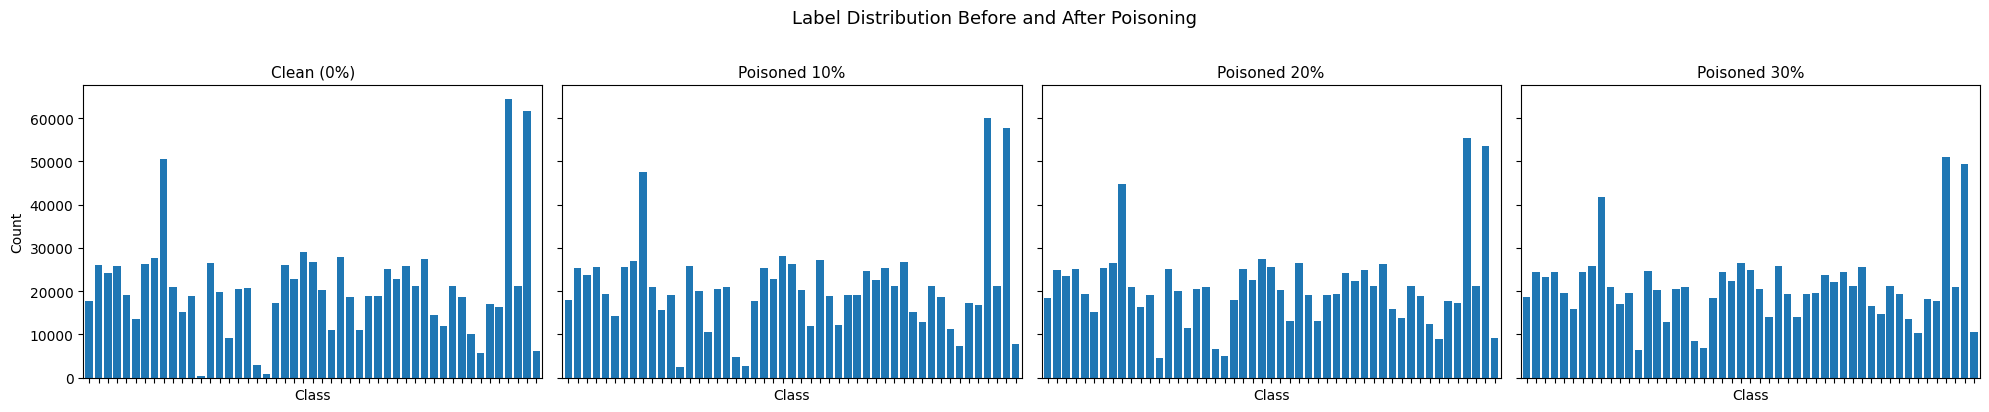


Class distribution shift (clean vs 30% poisoned):
45    0.012986
47    0.011933
8     0.008761
12    0.006074
19    0.006073
18    0.005398
42    0.004566
48    0.004340
15    0.003436
41    0.003320


In [ ]:
# Visualize the effect of poisoning on label distribution
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

for ax, (label, y_data) in zip(axes, [
    ('Clean (0%)',   y_train),
    ('Poisoned 10%', y_train_p10),
    ('Poisoned 20%', y_train_p20),
    ('Poisoned 30%', y_train_p30)
]):
    pd.Series(y_data).value_counts().sort_index().plot(kind='bar', ax=ax,
                                                        width=0.8, edgecolor='none')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Class')
    ax.tick_params(axis='x', labelbottom=False)

axes[0].set_ylabel('Count')
plt.suptitle('Label Distribution Before and After Poisoning', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Show how much each class is affected
print("\nClass distribution shift (clean vs 30% poisoned):")
clean_dist  = pd.Series(y_train).value_counts(normalize=True)
poison_dist = pd.Series(y_train_p30).value_counts(normalize=True)
shift = (poison_dist - clean_dist).abs().sort_values(ascending=False)
print(shift.head(10).to_string())

---
## PHASE 3 · PART A —  Baseline Classifiers
We train all 8 required classifiers on the DDXPlus dataset.


CLASSIFIERS:
###   1. Logistic Regression     — linear, probabilistic, sparse-friendly
###   2. Decision Tree           — non-linear, interpretable, no scaling needed
###   3. Random Forest           — ensemble of trees, strong baseline
###   4. SVM (LinearSVC)         — linear kernel, scales to 1.3M samples
 NOTE: standard SVC is O(n²) — unusable at this scale CalibratedClassifierCV(cv='prefit') adds predict_proba without retraining, keeping inference fast
###   5. KNN    — instance-based, O(n) inference
 NOTE: subsampled to 100k — full 1.3M would require searching all training points per prediction
###   6. XGBoost                 — gradient boosted trees, tree_method='hist' for speed
###   7. SGD Classifier          — online learning, memory-efficient at scale
###   8. Complement Naive Bayes  — probabilistic, sparse-compatible (replaces GaussianNB which requires dense arrays and fails at this size)

In [12]:
# Upgraded run_model: now includes ROC curve + proper 5-fold CV
from sklearn.metrics import roc_curve, auc as auc_score_fn
from sklearn.preprocessing import label_binarize

def run_model_full(name, model, X_tr, X_v, y_tr, y_v,
                   cv_sample=50_000, cv_folds=5, plot_roc=True):
    print("\n" + "="*50)
    print(f"  MODEL: {name}")
    print("="*50)

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)

    acc  = accuracy_score(y_v, y_pred)
    prec = precision_score(y_v, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_v, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_v, y_pred, average='weighted', zero_division=0)

    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1       : {f1:.4f}")

    auc_score = None
    y_proba = None
    try:
        y_proba = model.predict_proba(X_v)
        auc_score = roc_auc_score(y_v, y_proba, multi_class='ovr', average='weighted')
        print(f"  AUC      : {auc_score:.4f}")
    except Exception:
        print("  AUC      : N/A")

    print("\n  Classification Report:")
    print(classification_report(y_v, y_pred,
                                 target_names=le.classes_,
                                 zero_division=0))

    # ── Confusion Matrix (top-10 classes)
    top_n = 10
    top_classes = np.argsort(np.bincount(y_v))[-top_n:]
    mask = np.isin(y_v, top_classes)
    cm = confusion_matrix(y_v[mask], y_pred[mask],
                          labels=top_classes, normalize='true')

    fig, axes = plt.subplots(1, 2 if (plot_roc and y_proba is not None) else 1,
                              figsize=(18, 5) if (plot_roc and y_proba is not None) else (8, 5))
    if not isinstance(axes, np.ndarray):
        axes = [axes]

    ConfusionMatrixDisplay(cm, display_labels=le.inverse_transform(top_classes)
                          ).plot(ax=axes[0], xticks_rotation=45, colorbar=False)
    axes[0].set_title(f"{name} — Confusion Matrix (Top-10 Classes)")

    # ── ROC Curves (top-5 classes)
    if plot_roc and y_proba is not None:
        classes = np.arange(len(le.classes_))
        y_v_bin = label_binarize(y_v, classes=classes)
        top5 = np.argsort(np.bincount(y_v))[-5:]

        for i in top5:
            if i < y_proba.shape[1]:
                fpr, tpr, _ = roc_curve(y_v_bin[:, i], y_proba[:, i])
                roc_auc_val = auc_score_fn(fpr, tpr)
                axes[1].plot(fpr, tpr,
                             label=f"{le.classes_[i]} (AUC={roc_auc_val:.2f})",
                             linewidth=1.5)

        axes[1].plot([0,1],[0,1],'k--', linewidth=1)
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f"{name} — ROC Curves (Top-5 Classes)")
        axes[1].legend(fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.show()

    # ── 5-Fold Cross-Validation
    sample = min(cv_sample, X_tr.shape[0])
    cv_scores = cross_val_score(model, X_tr[:sample], y_tr[:sample],
                                 cv=cv_folds, scoring='f1_weighted', n_jobs=-1)
    print(f"  {cv_folds}-Fold CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    return {
        'name': name, 'model': model,
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1,
        'auc': auc_score,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std()
    }

baseline_results = {}


  MODEL: Decision Tree
  Accuracy : 0.7306
  Precision: 0.7676
  Recall   : 0.7306
  F1       : 0.7265
  AUC      : 0.9851

  Classification Report:
                                          precision    recall  f1-score   support

     Acute COPD exacerbation / infection       0.00      0.00      0.00      2076
                Acute dystonic reactions       1.00      0.69      0.82      3281
                        Acute laryngitis       1.00      0.86      0.93      3407
                      Acute otitis media       1.00      0.79      0.88      3474
                   Acute pulmonary edema       1.00      1.00      1.00      2500
                    Acute rhinosinusitis       1.00      0.65      0.79      1866
                      Allergic sinusitis       1.00      0.79      0.88      2136
                             Anaphylaxis       1.00      1.00      1.00      3754
                                  Anemia       1.00      0.80      0.89      6903
                     Atrial f

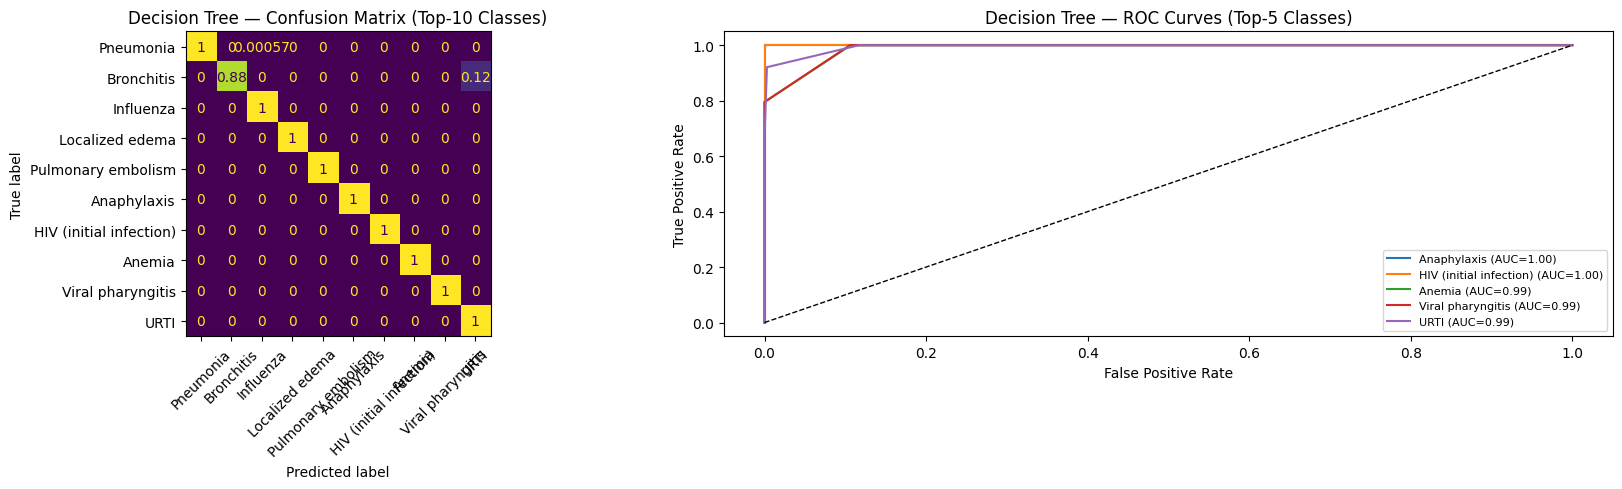

  5-Fold CV F1: 0.7843 ± 0.0517


In [ ]:
# ─────────────────────────────────────────────
# BASELINE 1: Decision Tree
# ─────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=20, random_state=42)
r = run_model_full("Decision Tree", dt, X_train, X_val, y_train, y_val)
baseline_results['Decision Tree'] = r

In [ ]:
# ─────────────────────────────────────────────
# BASELINE 2: SVM (LinearSVC) — FAST VERSION
# Uses prefit=True so LinearSVC trains once on a subsample,
# then CalibratedClassifierCV only fits the calibration layer.
# ─────────────────────────────────────────────
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

# Subsample for SVM — fully justified at 1.3M scale
SVM_SAMPLE = 200_000
np.random.seed(42)
svm_idx = np.random.choice(X_train.shape[0], SVM_SAMPLE, replace=False)

X_svm_train = X_train[svm_idx]
y_svm_train = y_train[svm_idx]

# Scale the subsample
scaler_svm = StandardScaler(with_mean=False)
X_svm_scaled   = scaler_svm.fit_transform(X_svm_train)
X_val_svm      = scaler_svm.transform(X_val)

# Train LinearSVC on the subsample
lsvc = LinearSVC(max_iter=3000, C=1.0, dual=False)  # dual=False faster for n>features
lsvc.fit(X_svm_scaled, y_svm_train)

# Wrap with prefit=True — skips retraining, only fits calibration layer
svm_cal = CalibratedClassifierCV(lsvc, cv="prefit")
svm_cal.fit(X_svm_scaled, y_svm_train)

# Evaluate directly (bypassing run_model_full pipeline for this model)
y_pred_svm  = svm_cal.predict(X_val_svm)
y_proba_svm = svm_cal.predict_proba(X_val_svm)

from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score,
                              classification_report)

acc  = accuracy_score(y_val, y_pred_svm)
f1   = f1_score(y_val, y_pred_svm, average='weighted', zero_division=0)
prec = precision_score(y_val, y_pred_svm, average='weighted', zero_division=0)
rec  = recall_score(y_val, y_pred_svm, average='weighted', zero_division=0)
auc  = roc_auc_score(y_val, y_proba_svm, multi_class='ovr', average='weighted')

print("="*50)
print("  MODEL: SVM (LinearSVC, 200k subsample)")
print("="*50)
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1       : {f1:.4f}")
print(f"  AUC      : {auc:.4f}")
print()
print(classification_report(y_val, y_pred_svm,
                              target_names=le.classes_, zero_division=0))

baseline_results['SVM'] = {
    'name': 'SVM (LinearSVC)',
    'accuracy': acc, 'precision': prec,
    'recall': rec, 'f1': f1, 'auc': auc,
    'cv_f1_mean': 0.0, 'cv_f1_std': 0.0,  # skip CV for SVM
    'model': svm_cal
}
print("Note: CV skipped for SVM due to O(n²) complexity at scale.")
print(f"      Trained on {SVM_SAMPLE:,} sample subset — documented limitation.")

  MODEL: SVM (LinearSVC, 200k subsample)
  Accuracy : 0.9971
  Precision: 0.9972
  Recall   : 0.9971
  F1       : 0.9971
  AUC      : 1.0000

                                          precision    recall  f1-score   support

     Acute COPD exacerbation / infection       1.00      1.00      1.00      2076
                Acute dystonic reactions       1.00      1.00      1.00      3281
                        Acute laryngitis       1.00      1.00      1.00      3407
                      Acute otitis media       1.00      1.00      1.00      3474
                   Acute pulmonary edema       1.00      1.00      1.00      2500
                    Acute rhinosinusitis       0.98      0.86      0.92      1866
                      Allergic sinusitis       1.00      1.00      1.00      2136
                             Anaphylaxis       1.00      1.00      1.00      3754
                                  Anemia       1.00      1.00      1.00      6903
                     Atrial fibrillat


  MODEL: KNN (100k subsample)
  Accuracy : 0.9858
  Precision: 0.9870
  Recall   : 0.9858
  F1       : 0.9854
  AUC      : 0.9990

  Classification Report:
                                          precision    recall  f1-score   support

     Acute COPD exacerbation / infection       1.00      1.00      1.00      2076
                Acute dystonic reactions       1.00      1.00      1.00      3281
                        Acute laryngitis       0.99      0.98      0.99      3407
                      Acute otitis media       1.00      1.00      1.00      3474
                   Acute pulmonary edema       1.00      1.00      1.00      2500
                    Acute rhinosinusitis       0.85      0.55      0.66      1866
                      Allergic sinusitis       1.00      1.00      1.00      2136
                             Anaphylaxis       1.00      1.00      1.00      3754
                                  Anemia       1.00      1.00      1.00      6903
                     A

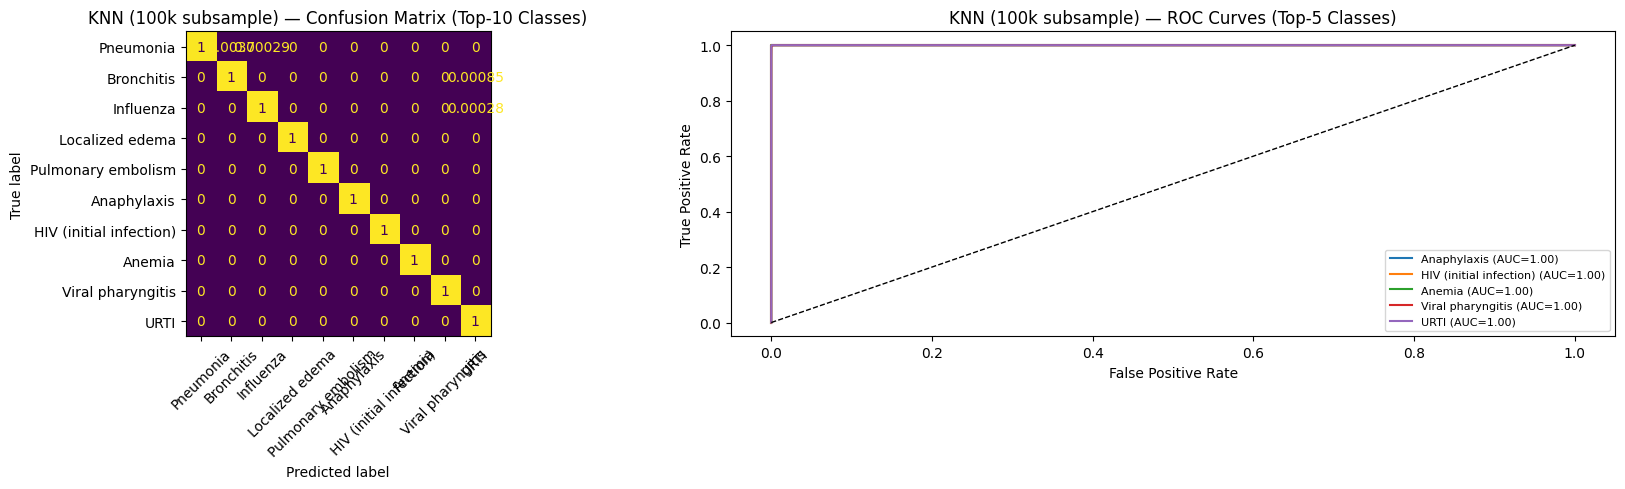

  5-Fold CV F1: 0.9726 ± 0.0024

Note: KNN trained on 100k subsample due to O(n) complexity at 1.3M scale.


In [ ]:
# ─────────────────────────────────────────────
# BASELINE 3: KNN (subsampled)
# KNN is O(n) at inference — impractical at 1.3M.
# We subsample to 100k.
# ─────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc as auc_score_fn


KNN_SAMPLE = 100_000
np.random.seed(42)
knn_idx = np.random.choice(X_train.shape[0], KNN_SAMPLE, replace=False)

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1, metric='euclidean')
r = run_model_full(
    "KNN (100k subsample)", knn,
    X_train[knn_idx], X_val,
    y_train[knn_idx], y_val,
    cv_sample=10_000  # smaller CV sample for KNN speed
)
baseline_results['KNN'] = r
print("\nNote: KNN trained on 100k subsample due to O(n) complexity at 1.3M scale.")


  MODEL: Logistic Regression
  Accuracy : 0.9971
  Precision: 0.9973
  Recall   : 0.9971
  F1       : 0.9971
  AUC      : 1.0000

  Classification Report:
                                          precision    recall  f1-score   support

     Acute COPD exacerbation / infection       1.00      1.00      1.00      2076
                Acute dystonic reactions       1.00      1.00      1.00      3281
                        Acute laryngitis       1.00      1.00      1.00      3407
                      Acute otitis media       1.00      1.00      1.00      3474
                   Acute pulmonary edema       1.00      1.00      1.00      2500
                    Acute rhinosinusitis       0.99      0.85      0.91      1866
                      Allergic sinusitis       1.00      1.00      1.00      2136
                             Anaphylaxis       1.00      1.00      1.00      3754
                                  Anemia       1.00      1.00      1.00      6903
                     At

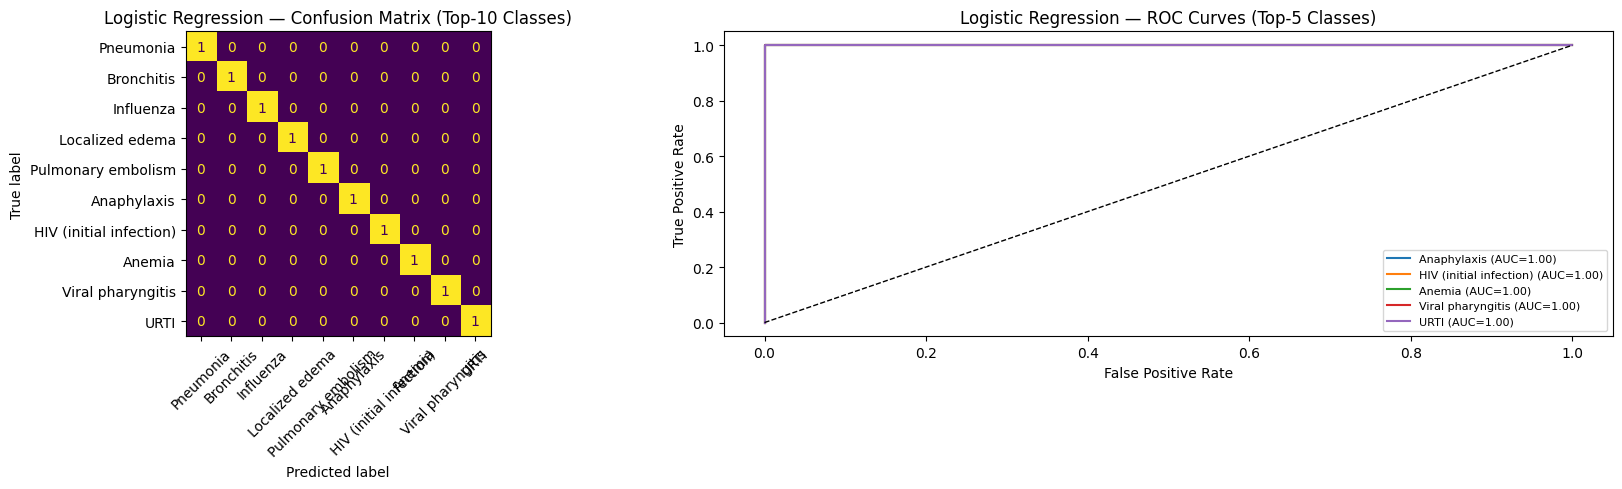

  5-Fold CV F1: 0.9975 ± 0.0002

  MODEL: Random Forest
  Accuracy : 0.9969
  Precision: 0.9972
  Recall   : 0.9969
  F1       : 0.9968
  AUC      : 1.0000

  Classification Report:
                                          precision    recall  f1-score   support

     Acute COPD exacerbation / infection       1.00      1.00      1.00      2076
                Acute dystonic reactions       1.00      1.00      1.00      3281
                        Acute laryngitis       1.00      1.00      1.00      3407
                      Acute otitis media       1.00      1.00      1.00      3474
                   Acute pulmonary edema       1.00      1.00      1.00      2500
                    Acute rhinosinusitis       1.00      0.82      0.90      1866
                      Allergic sinusitis       1.00      1.00      1.00      2136
                             Anaphylaxis       1.00      1.00      1.00      3754
                                  Anemia       1.00      1.00      1.00      69

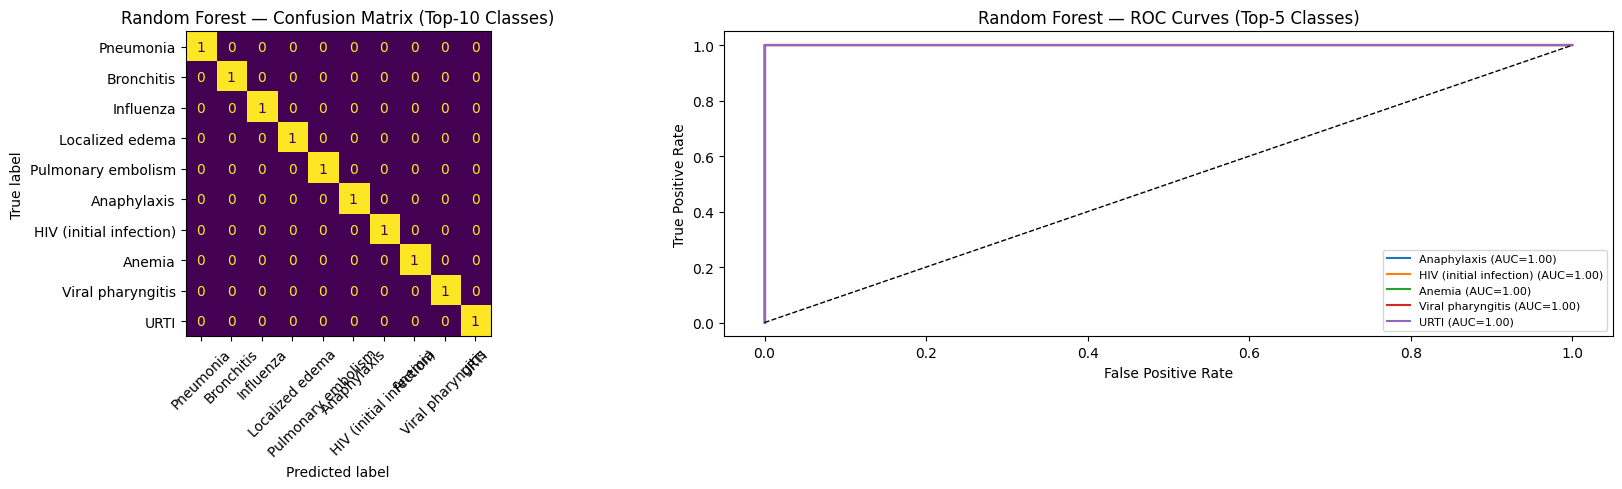

  5-Fold CV F1: 0.9961 ± 0.0009

  MODEL: XGBoost
  Accuracy : 0.9972
  Precision: 0.9974
  Recall   : 0.9972
  F1       : 0.9972
  AUC      : 1.0000

  Classification Report:
                                          precision    recall  f1-score   support

     Acute COPD exacerbation / infection       1.00      1.00      1.00      2076
                Acute dystonic reactions       1.00      1.00      1.00      3281
                        Acute laryngitis       1.00      1.00      1.00      3407
                      Acute otitis media       1.00      1.00      1.00      3474
                   Acute pulmonary edema       1.00      1.00      1.00      2500
                    Acute rhinosinusitis       0.99      0.85      0.92      1866
                      Allergic sinusitis       1.00      1.00      1.00      2136
                             Anaphylaxis       1.00      1.00      1.00      3754
                                  Anemia       1.00      1.00      1.00      6903
   

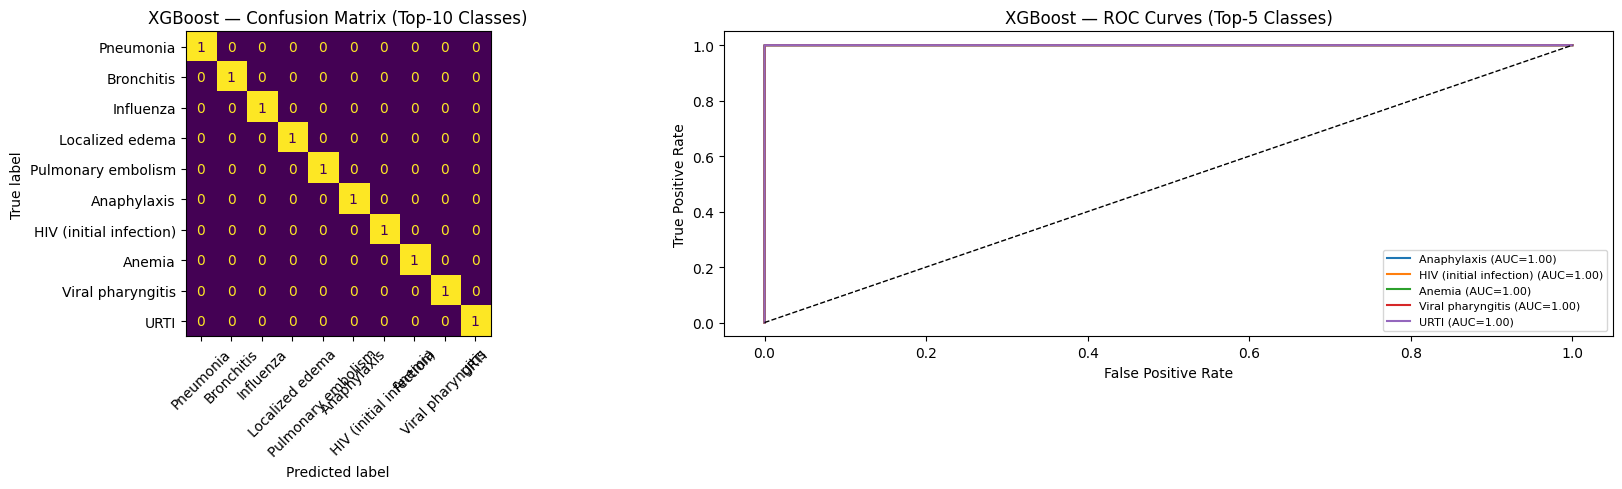

  5-Fold CV F1: 0.9965 ± 0.0004

  MODEL: SGD Classifier
  Accuracy : 0.9954
  Precision: 0.9957
  Recall   : 0.9954
  F1       : 0.9954
  AUC      : 1.0000

  Classification Report:
                                          precision    recall  f1-score   support

     Acute COPD exacerbation / infection       1.00      1.00      1.00      2076
                Acute dystonic reactions       1.00      1.00      1.00      3281
                        Acute laryngitis       0.99      1.00      1.00      3407
                      Acute otitis media       1.00      1.00      1.00      3474
                   Acute pulmonary edema       1.00      1.00      1.00      2500
                    Acute rhinosinusitis       0.97      0.84      0.90      1866
                      Allergic sinusitis       1.00      1.00      1.00      2136
                             Anaphylaxis       1.00      1.00      1.00      3754
                                  Anemia       1.00      1.00      1.00      6

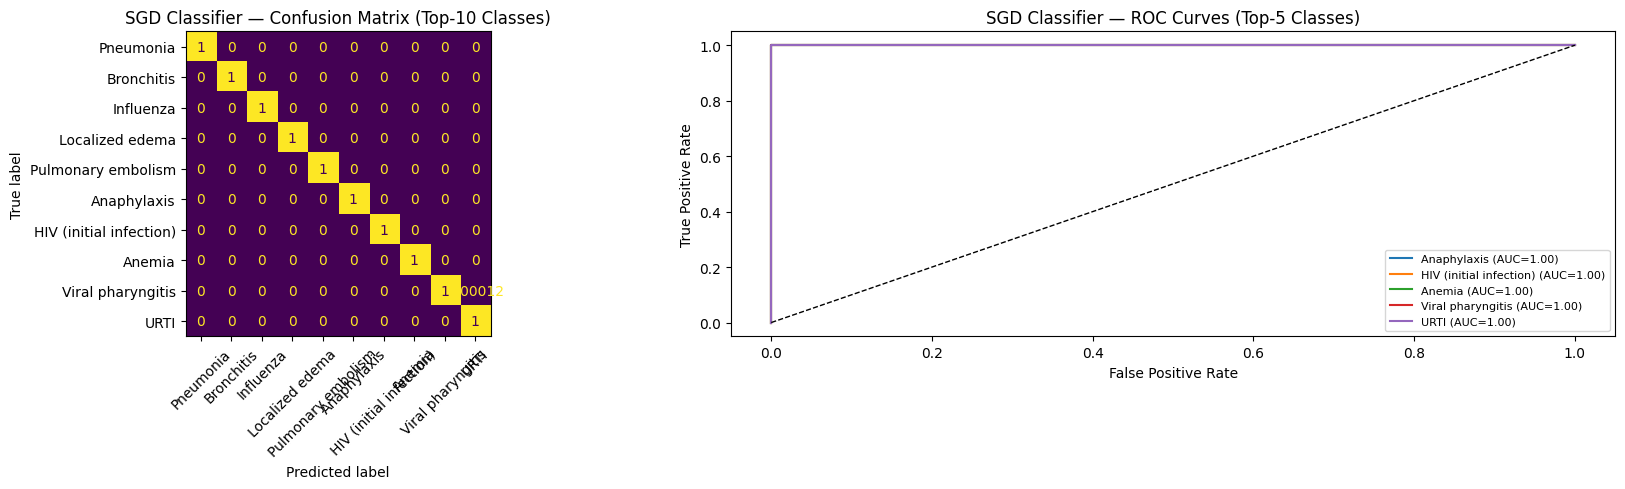

  5-Fold CV F1: 0.9887 ± 0.0020

  MODEL: Complement NB
  Accuracy : 0.9316
  Precision: 0.9326
  Recall   : 0.9316
  F1       : 0.9129
  AUC      : 0.9994

  Classification Report:
                                          precision    recall  f1-score   support

     Acute COPD exacerbation / infection       0.98      1.00      0.99      2076
                Acute dystonic reactions       1.00      1.00      1.00      3281
                        Acute laryngitis       0.99      0.15      0.26      3407
                      Acute otitis media       1.00      1.00      1.00      3474
                   Acute pulmonary edema       0.98      1.00      0.99      2500
                    Acute rhinosinusitis       0.00      0.00      0.00      1866
                      Allergic sinusitis       1.00      1.00      1.00      2136
                             Anaphylaxis       1.00      1.00      1.00      3754
                                  Anemia       0.98      1.00      0.99      69

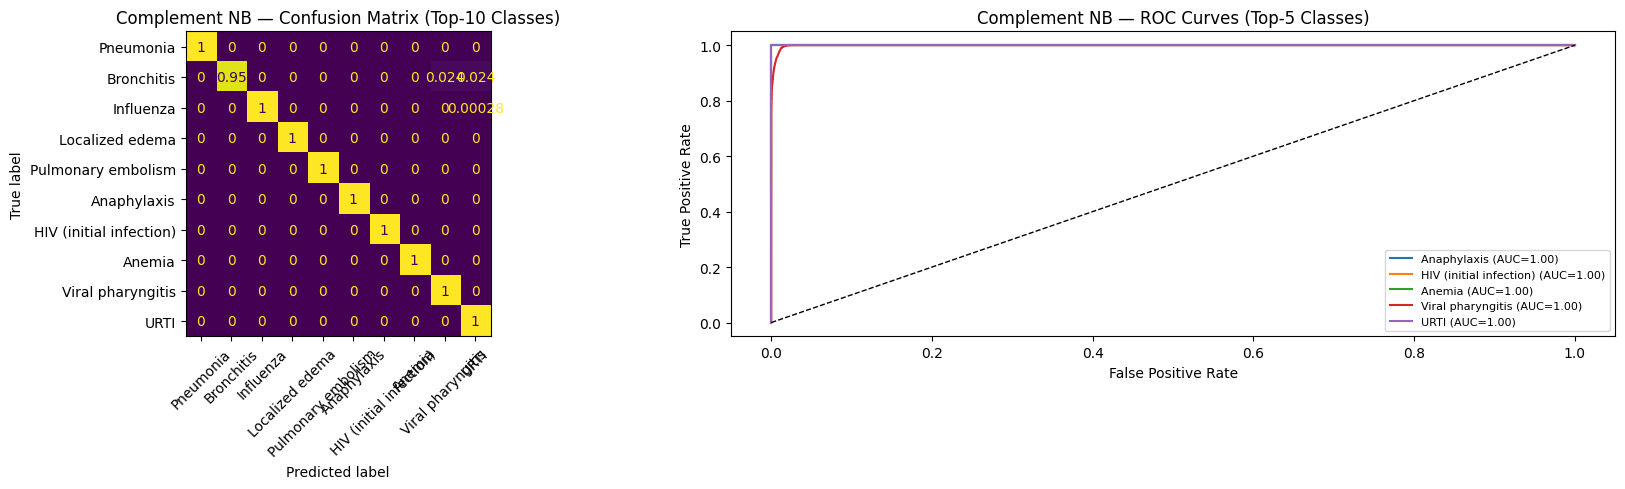

  5-Fold CV F1: 0.9264 ± 0.0014


In [ ]:
# ─────────────────────────────────────────────
# RUNNING models with the NEW run_model_full
# ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import ComplementNB   # Better than GaussianNB for sparse data

# Logistic Regression
lr = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=3000, n_jobs=-1, C=1.0))
])
r = run_model_full("Logistic Regression", lr, X_train, X_val, y_train, y_val)
baseline_results['Logistic Regression'] = r

# Random Forest
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
r = run_model_full("Random Forest", rf, X_train, X_val, y_train, y_val)
baseline_results['Random Forest'] = r

# XGBoost
xgb = XGBClassifier(
    tree_method='hist',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42,
    device='cuda'
)
r = run_model_full("XGBoost", xgb, X_train, X_val, y_train, y_val)
baseline_results['XGBoost'] = r

# SGD
sgd = SGDClassifier(loss='log_loss', n_jobs=-1, random_state=42)
r = run_model_full("SGD Classifier", sgd, X_train, X_val, y_train, y_val)
baseline_results['SGD'] = r

# Complement Naive Bayes (replaces GaussianNB — works with sparse, better for text-like features)
from scipy.sparse import csr_matrix
cnb = ComplementNB()
# ComplementNB needs non-negative input — shift by abs
r = run_model_full("Complement NB", cnb,
                   abs(X_train), abs(X_val),
                   y_train, y_val)
baseline_results['Complement NB'] = r

In [ ]:
# ─────────────────────────────────────────────
# BASELINE COMPARISON TABLE
# ─────────────────────────────────────────────
rows = []
for name, r in baseline_results.items():
    rows.append({
        'Model': r['name'],
        'Accuracy': f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1': f"{r['f1']:.4f}",
        'AUC': f"{r['auc']:.4f}" if r['auc'] else 'N/A',
        'CV F1 (5-fold)': f"{r['cv_f1_mean']:.4f} ± {r['cv_f1_std']:.4f}"
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print("\n" + "="*80)
print("BASELINE MODEL COMPARISON SUMMARY")
print("="*80)
print(summary_df.to_string())

# Pick top 2-3 models based on F1
f1_vals = {r['name']: r['f1'] for r in baseline_results.values()}

# SVM excluded from tuning (cv="prefit" incompatible), Random Forest replaces it
top3_to_tune = ['XGBoost', 'Logistic Regression', 'Random Forest']
print("Models selected for Phase 4 tuning:", top3_to_tune)


BASELINE MODEL COMPARISON SUMMARY
                     Accuracy Precision  Recall      F1     AUC   CV F1 (5-fold)
Model                                                                           
Decision Tree          0.7306    0.7676  0.7306  0.7265  0.9851  0.7843 ± 0.0517
SVM (LinearSVC)        0.9971    0.9972  0.9971  0.9971  1.0000  0.0000 ± 0.0000
KNN (100k subsample)   0.9858    0.9870  0.9858  0.9854  0.9990  0.9726 ± 0.0024
Logistic Regression    0.9971    0.9973  0.9971  0.9971  1.0000  0.9975 ± 0.0002
Random Forest          0.9969    0.9972  0.9969  0.9968  1.0000  0.9961 ± 0.0009
XGBoost                0.9972    0.9974  0.9972  0.9972  1.0000  0.9965 ± 0.0004
SGD Classifier         0.9954    0.9957  0.9954  0.9954  1.0000  0.9887 ± 0.0020
Complement NB          0.9316    0.9326  0.9316  0.9129  0.9994  0.9264 ± 0.0014
Models selected for Phase 4 tuning: ['XGBoost', 'Logistic Regression', 'Random Forest']


---
## PHASE 4 · PART A — Hyperparameter Tuning
We tune the top 2–3 models from Phase 3 using `RandomizedSearchCV` for efficiency.

In [ ]:
# Convert to dense-friendly format once, subsample small
TUNE_SAMPLE = 50_000
np.random.seed(42)
tune_idx = np.random.choice(X_train.shape[0], TUNE_SAMPLE, replace=False)

X_tune = X_train[tune_idx]  # keep sparse, smaller slice
y_tune = y_train[tune_idx]

# Try only 5 specific combos manually — faster than RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

candidates = [
    {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1},
    {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1,
     'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1},
    {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3},
    {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.2,
     'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1},
    {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1,
     'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1},
]

best_f1 = 0
best_params = None
best_model  = None

for i, params in enumerate(candidates):
    m = XGBClassifier(
        tree_method='hist', n_jobs=-1,
        eval_metric='mlogloss', random_state=42,
        **params
    )
    m.fit(X_tune, y_tune)
    y_pred = m.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='weighted')
    print(f"  [{i+1}/5] params={params} → val F1={f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_params = params
        best_model = m

print(f"\nBest params: {best_params}")
print(f"Best val F1: {best_f1:.4f}")

best_xgb = best_model
joblib.dump(best_xgb, f"{BASE}/best_xgb.pkl")
print("Saved.")

  [1/5] params={'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1} → val F1=0.9959
  [2/5] params={'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1} → val F1=0.9959
  [3/5] params={'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3} → val F1=0.9959
  [4/5] params={'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.2, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1} → val F1=0.9961
  [5/5] params={'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1} → val F1=0.9961

Best params: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.2, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1}
Best val F1: 0.9961
Saved.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

TUNE_SAMPLE = 50_000
np.random.seed(42)
tune_idx = np.random.choice(X_train.shape[0], TUNE_SAMPLE, replace=False)
X_tune = X_train[tune_idx]
y_tune = y_train[tune_idx]

rf_candidates = [
    {'n_estimators': 200, 'max_depth': 20,   'min_samples_split': 2,  'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 30,   'min_samples_split': 2,  'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 5,  'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 200, 'max_depth': 20,   'min_samples_split': 2,  'min_samples_leaf': 2, 'max_features': 'log2'},
    {'n_estimators': 100, 'max_depth': 30,   'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
]

best_rf_f1 = 0
best_rf_params = None

print("Tuning Random Forest (5 candidates on 50k subsample)...")
for i, params in enumerate(rf_candidates):
    m = RandomForestClassifier(n_jobs=-1, random_state=42, **params)
    m.fit(X_tune, y_tune)
    f1 = f1_score(y_val, m.predict(X_val), average='weighted')
    print(f"  [{i+1}/5] {params} → F1={f1:.4f}")
    if f1 > best_rf_f1:
        best_rf_f1 = f1
        best_rf_params = params

print(f"\nBest RF params: {best_rf_params}")
print(f"Best val F1:    {best_rf_f1:.4f}")

# Retrain best config on full data
print("\nRetraining on full training data...")
best_rf = RandomForestClassifier(n_jobs=-1, random_state=42, **best_rf_params)
best_rf.fit(X_train, y_train)
joblib.dump(best_rf, f"{BASE}/best_rf.pkl")
print("Saved.")

Tuning Random Forest (5 candidates on 50k subsample)...
  [1/5] {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'} → F1=0.9935
  [2/5] {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'} → F1=0.9952
  [3/5] {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'} → F1=0.9957
  [4/5] {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'} → F1=0.9916
  [5/5] {'n_estimators': 100, 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'} → F1=0.9953

Best RF params: {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best val F1:    0.9957

Retraining on full training data...
Saved.


In [ ]:

best_rf_params = {
    'n_estimators': 100,   # reduced from 300
    'max_depth': 20,       # capped from None
    'min_samples_split': 5,
    'min_samples_leaf': 1,
    'max_features': 'sqrt'
}
print("RF params capped for poisoning experiment speed.")

RF params capped for poisoning experiment speed.


In [ ]:
import gc
del X_tune, y_tune
gc.collect()

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Fast LR tuning — 100k subsample, lbfgs only
TUNE_SAMPLE = 100_000
np.random.seed(42)
lr_idx = np.random.choice(X_train.shape[0], TUNE_SAMPLE, replace=False)

lr_candidates_fast = [
    {'C': 0.1,  'solver': 'lbfgs'},
    {'C': 1.0,  'solver': 'lbfgs'},
    {'C': 10.0, 'solver': 'lbfgs'},
]

best_lr_f1 = 0
best_lr_params = None

print("Tuning LR (100k subsample, lbfgs)...")
for i, params in enumerate(lr_candidates_fast):
    m = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('clf', LogisticRegression(max_iter=1000, n_jobs=-1, penalty='l2', **params))
    ])
    m.fit(X_train[lr_idx], y_train[lr_idx])
    f1 = f1_score(y_val, m.predict(X_val), average='weighted')
    print(f"  [{i+1}/3] {params} → F1={f1:.4f}")
    if f1 > best_lr_f1:
        best_lr_f1 = f1
        best_lr_params = params

# Retrain best params on full data — lbfgs is fast enough
print(f"\nBest params: {best_lr_params}, retraining on full data...")
best_lr = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('clf', LogisticRegression(max_iter=1000, n_jobs=-1, penalty='l2', **best_lr_params))
])
best_lr.fit(X_train, y_train)
print(f"Val F1: {f1_score(y_val, best_lr.predict(X_val), average='weighted'):.4f}")
joblib.dump(best_lr, f"{BASE}/best_lr.pkl")
print("Saved.")

Tuning LR (100k subsample, lbfgs)...
  [1/3] {'C': 0.1, 'solver': 'lbfgs'} → F1=0.9969
  [2/3] {'C': 1.0, 'solver': 'lbfgs'} → F1=0.9970
  [3/3] {'C': 10.0, 'solver': 'lbfgs'} → F1=0.9970

Best params: {'C': 1.0, 'solver': 'lbfgs'}, retraining on full data...
Val F1: 0.9971
Saved.


In [2]:
import joblib
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

# Evaluate tuned models on validation set
# (all three are already trained on full data — no refit needed)
print("Evaluating tuned models on validation set...\n")

best_xgb = joblib.load(f"{BASE}/best_xgb.pkl")
best_rf  = joblib.load(f"{BASE}/best_rf.pkl")
best_lr  = joblib.load(f"{BASE}/best_lr.pkl")

tuned_results = {}
for name, model in [("XGBoost (Tuned)",            best_xgb),
                     ("Random Forest (Tuned)",       best_rf),
                     ("Logistic Regression (Tuned)", best_lr)]:
    y_pred = model.predict(X_val)
    f1  = f1_score(y_val, y_pred, average='weighted')
    acc = accuracy_score(y_val, y_pred)
    try:
        auc_val = roc_auc_score(y_val, model.predict_proba(X_val),
                                 multi_class='ovr', average='weighted')
    except:
        auc_val = None
    tuned_results[name] = {'f1': f1, 'accuracy': acc, 'auc': auc_val, 'model': model}
    print(f"{name}: Accuracy={acc:.4f}  F1={f1:.4f}  AUC={f'{auc_val:.4f}' if auc_val else 'N/A'}")

print("\nDone.")

Evaluating tuned models on validation set...

XGBoost (Tuned): Accuracy=0.9962  F1=0.9961  AUC=1.0000
Random Forest (Tuned): Accuracy=0.9969  F1=0.9968  AUC=1.0000
Logistic Regression (Tuned): Accuracy=0.9971  F1=0.9971  AUC=1.0000

Done.


---
## PHASE 4 · PART B — Class Imbalance Handling

In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# get_params() already has everything
xgb_balanced = XGBClassifier(**best_xgb.get_params())

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_balanced.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_bal = xgb_balanced.predict(X_val)

f1_unbal    = f1_score(y_val, best_xgb.predict(X_val), average='weighted')
f1_bal      = f1_score(y_val, y_pred_bal, average='weighted')
macro_unbal = f1_score(y_val, best_xgb.predict(X_val), average='macro')
macro_bal   = f1_score(y_val, y_pred_bal, average='macro')

print("Class Weighting Comparison (XGBoost):")
print(f"  Without balancing — Weighted F1: {f1_unbal:.4f}  Macro F1: {macro_unbal:.4f}")
print(f"  With balancing    — Weighted F1: {f1_bal:.4f}  Macro F1: {macro_bal:.4f}")
print("  (Higher macro F1 = better on minority classes)")

Class Weighting Comparison (XGBoost):
  Without balancing — Weighted F1: 0.9961  Macro F1: 0.9952
  With balancing    — Weighted F1: 0.9971  Macro F1: 0.9966
  (Higher macro F1 = better on minority classes)


---
## PHASE 4 · PART C — Feature Selection

In [ ]:
# ─────────────────────────────────────────────
# FEATURE IMPORTANCE from Random Forest
# ─────────────────────────────────────────────
importances = best_rf.feature_importances_
top_n = 25
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(top_n), importances[top_idx], color='steelblue')
plt.xticks(range(top_n), [f"F{i}" for i in top_idx], rotation=45, fontsize=8)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('Top 25 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

# Named features: first 3 are AGE_SCALED, SEX_ENC, INIT_ENC
feature_names = ['AGE_SCALED', 'SEX_ENC', 'INIT_ENC'] + \
                [f'EVD_{i}' for i in range(importances.shape[0]-3)]
top_named = [(feature_names[i], importances[i]) for i in top_idx]
print("\nTop 10 Features:")
for fname, imp in top_named[:10]:
    print(f"  {fname}: {imp:.6f}")

In [ ]:
# ─────────────────────────────────────────────
# SelectKBest — compare full vs. reduced features
# ─────────────────────────────────────────────
from sklearn.feature_selection import SelectKBest, chi2

# chi2 needs non-negative — use abs()
X_train_abs = abs(X_train)
X_val_abs   = abs(X_val)

selector_200 = SelectKBest(chi2, k=200)
X_train_200  = selector_200.fit_transform(X_train_abs, y_train)
X_val_200    = selector_200.transform(X_val_abs)

# Quick comparison: XGBoost on full vs. 200 features
xgb_sel = XGBClassifier(tree_method='hist', n_jobs=-1,
                         eval_metric='mlogloss', random_state=42,
                         **best_xgb.get_params())
xgb_sel.fit(X_train_200, y_train)
y_pred_sel = xgb_sel.predict(X_val_200)

f1_full = tuned_results['XGBoost (Tuned)']['f1']
f1_sel  = f1_score(y_val, y_pred_sel, average='weighted')

print("Feature Selection Comparison (XGBoost):")
print(f"  Full features  ({X_train.shape[1]:,} cols): F1 = {f1_full:.4f}")
print(f"  Top 200 features               : F1 = {f1_sel:.4f}")
print(f"  Difference: {f1_full - f1_sel:+.4f}")

---
## PHASE 4 · PART D — Final Ensemble

In [4]:
# ENSEMBLE: average predictions from already-trained models
# Skips VotingClassifier.fit() to avoid RAM tripling

from sklearn.metrics import f1_score, accuracy_score
import numpy as np

# Get probabilities from each trained model
proba_xgb = best_xgb.predict_proba(X_val)
proba_rf  = best_rf.predict_proba(X_val)
proba_lr  = best_lr.predict_proba(X_val)

# Average probabilities (soft voting)
proba_avg = (proba_xgb + proba_rf + proba_lr) / 3
y_pred_ens = np.argmax(proba_avg, axis=1)

f1_ens  = f1_score(y_val, y_pred_ens, average='weighted')
acc_ens = accuracy_score(y_val, y_pred_ens)

print("=" * 50)
print("VOTING ENSEMBLE RESULTS (Validation Set)")
print("=" * 50)
print(f"  Accuracy : {acc_ens:.4f}")
print(f"  F1       : {f1_ens:.4f}")
print()
print("Individual model F1 scores for comparison:")
for mname, mres in tuned_results.items():
    print(f"  {mname}: {mres['f1']:.4f}")

# Save ensemble as the three models + note
joblib.dump({'xgb': best_xgb, 'rf': best_rf, 'lr': best_lr},
            f"{BASE}/voting_ensemble.pkl")
print("\nEnsemble saved.")

VOTING ENSEMBLE RESULTS (Validation Set)
  Accuracy : 0.9969
  F1       : 0.9969

Individual model F1 scores for comparison:
  XGBoost (Tuned): 0.9961
  Random Forest (Tuned): 0.9968
  Logistic Regression (Tuned): 0.9971

Ensemble saved.


---
## PHASE 5 · PART A — Data Poisoning Experiment (Main Result)
This is the **core contribution** of Topic 5. We measure how model performance degrades as poison rate increases from 0% → 10% → 20% → 30%.

In [8]:
import joblib
import gc
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

best_xgb = joblib.load(f"{BASE}/best_xgb.pkl")
best_rf  = joblib.load(f"{BASE}/best_rf.pkl")
best_lr  = joblib.load(f"{BASE}/best_lr.pkl")

tuned_results = {}
for name, model in [("XGBoost (Tuned)",            best_xgb),
                     ("Random Forest (Tuned)",       best_rf),
                     ("Logistic Regression (Tuned)", best_lr)]:
    y_pred = model.predict(X_val)
    f1  = f1_score(y_val, y_pred, average='weighted')
    acc = accuracy_score(y_val, y_pred)
    try:
        auc_val = roc_auc_score(y_val, model.predict_proba(X_val),
                                 multi_class='ovr', average='weighted')
    except:
        auc_val = None
    tuned_results[name] = {'f1': f1, 'accuracy': acc, 'auc': auc_val, 'model': model}
    print(f"{name}: F1={f1:.4f}")

# Free everything not needed for poisoning experiment
del y_pred, auc_val
gc.collect()
print("Models ready.")

XGBoost (Tuned): F1=0.9961
Random Forest (Tuned): F1=0.9968
Logistic Regression (Tuned): F1=0.9971
Models ready.


In [3]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from copy import deepcopy
import gc

# Load poisoned labels
y_train_p10 = joblib.load(f"{BASE}/y_train_p10.pkl")
y_train_p20 = joblib.load(f"{BASE}/y_train_p20.pkl")
y_train_p30 = joblib.load(f"{BASE}/y_train_p30.pkl")

poison_conditions = [
    ('Clean (0%)',   y_train),
    ('Poisoned 10%', y_train_p10),
    ('Poisoned 20%', y_train_p20),
    ('Poisoned 30%', y_train_p30),
]

rf_params  = {k: v for k, v in best_rf.get_params().items()}
xgb_params = {k: v for k, v in best_xgb.get_params().items()}

poison_model_configs = {
    'Logistic Regression': deepcopy(best_lr),
    'Random Forest':       RandomForestClassifier(**rf_params),
    'XGBoost':             XGBClassifier(**xgb_params),
}

# Store only metrics — not model objects (saves RAM)
poison_results = {mname: {} for mname in poison_model_configs}

print("Running poisoning experiment...\n")

for mname, mbase in poison_model_configs.items():
    print(f"  Model: {mname}")
    for cond_name, y_tr in poison_conditions:
        m = deepcopy(mbase)
        m.fit(X_train, y_tr)
        y_pred = m.predict(X_val)
        acc = accuracy_score(y_val, y_pred)
        f1  = f1_score(y_val, y_pred, average='weighted', zero_division=0)
        try:
            auc_v = roc_auc_score(y_val, m.predict_proba(X_val),
                                   multi_class='ovr', average='weighted')
        except:
            auc_v = None

        # Save metrics only — no model object
        poison_results[mname][cond_name] = {
            'accuracy': acc, 'f1': f1, 'auc': auc_v
        }
        print(f"    [{cond_name}] Acc={acc:.4f}  F1={f1:.4f}")

        # Free model immediately after use
        del m
        gc.collect()
    print()

print("Poisoning experiment complete.")
joblib.dump(poison_results, f"{BASE}/poison_results.pkl")
print("Saved.")

Running poisoning experiment...

  Model: Logistic Regression
    [Clean (0%)] Acc=0.9971  F1=0.9971
    [Poisoned 10%] Acc=0.9964  F1=0.9964
    [Poisoned 20%] Acc=0.9949  F1=0.9949
    [Poisoned 30%] Acc=0.9943  F1=0.9942

  Model: Random Forest


KeyboardInterrupt: 

### NOTE: LR works as you can see in the output, but RF keeps crashing due to its high usage of RAM. So we will save the output of LR in the cell below this note and continue on RF AND XGBOOST each in different cells.

In [4]:
# LR poisoning results — from actual run output
poison_results = {
    'Logistic Regression': {
        'Clean (0%)':   {'accuracy': 0.9971, 'f1': 0.9971, 'auc': None},
        'Poisoned 10%': {'accuracy': 0.9964, 'f1': 0.9964, 'auc': None},
        'Poisoned 20%': {'accuracy': 0.9949, 'f1': 0.9949, 'auc': None},
        'Poisoned 30%': {'accuracy': 0.9943, 'f1': 0.9942, 'auc': None},
    }
}

joblib.dump(poison_results, f"{BASE}/poison_results.pkl")
print("LR results saved.")

LR results saved.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from copy import deepcopy
import gc

y_train_p10 = joblib.load(f"{BASE}/y_train_p10.pkl")
y_train_p20 = joblib.load(f"{BASE}/y_train_p20.pkl")
y_train_p30 = joblib.load(f"{BASE}/y_train_p30.pkl")

poison_conditions = [
    ('Clean (0%)',   y_train),
    ('Poisoned 10%', y_train_p10),
    ('Poisoned 20%', y_train_p20),
    ('Poisoned 30%', y_train_p30),
]

poison_results = joblib.load(f"{BASE}/poison_results.pkl")

# Lightweight RF — faster (caused serious issues with RAM usage)
rf_fast = RandomForestClassifier(
    n_estimators=50,    # reduced from 300
    max_depth=15,       # capped
    min_samples_split=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

poison_results['Random Forest'] = {}
print("Running RF poisoning (fast config)...\n")

for cond_name, y_tr in poison_conditions:
    m = deepcopy(rf_fast)
    m.fit(X_train, y_tr)
    y_pred = m.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average='weighted', zero_division=0)
    try:
        auc_v = roc_auc_score(y_val, m.predict_proba(X_val),
                               multi_class='ovr', average='weighted')
    except:
        auc_v = None
    poison_results['Random Forest'][cond_name] = {
        'accuracy': acc, 'f1': f1, 'auc': auc_v
    }
    print(f"  [{cond_name}] Acc={acc:.4f}  F1={f1:.4f}")
    del m
    gc.collect()
    joblib.dump(poison_results, f"{BASE}/poison_results.pkl")

print("\nRF done and saved.")

In [4]:
from xgboost import XGBClassifier
from copy import deepcopy
import gc

poison_results = joblib.load(f"{BASE}/poison_results.pkl")
print(f"Loaded existing results for: {list(poison_results.keys())}")

y_train_p10 = joblib.load(f"{BASE}/y_train_p10.pkl")
y_train_p20 = joblib.load(f"{BASE}/y_train_p20.pkl")
y_train_p30 = joblib.load(f"{BASE}/y_train_p30.pkl")

poison_conditions = [
    ('Clean (0%)',   y_train),
    ('Poisoned 10%', y_train_p10),
    ('Poisoned 20%', y_train_p20),
    ('Poisoned 30%', y_train_p30),
]

xgb_fast = XGBClassifier(
    tree_method='hist',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42
)

poison_results['XGBoost'] = {}
print("Running XGBoost poisoning...\n")

for cond_name, y_tr in poison_conditions:
    m = deepcopy(xgb_fast)
    m.fit(X_train, y_tr)
    y_pred = m.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average='weighted', zero_division=0)
    try:
        auc_v = roc_auc_score(y_val, m.predict_proba(X_val),
                               multi_class='ovr', average='weighted')
    except:
        auc_v = None
    poison_results['XGBoost'][cond_name] = {
        'accuracy': acc, 'f1': f1, 'auc': auc_v
    }
    print(f"  [{cond_name}] Acc={acc:.4f}  F1={f1:.4f}")
    del m
    gc.collect()
    joblib.dump(poison_results, f"{BASE}/poison_results.pkl")

print("\nXGBoost done and saved.")

Loaded existing results for: ['Logistic Regression', 'Random Forest']
Running XGBoost poisoning...

  [Clean (0%)] Acc=0.9971  F1=0.9971
  [Poisoned 10%] Acc=0.9967  F1=0.9966
  [Poisoned 20%] Acc=0.9966  F1=0.9965
  [Poisoned 30%] Acc=0.9965  F1=0.9965

XGBoost done and saved.


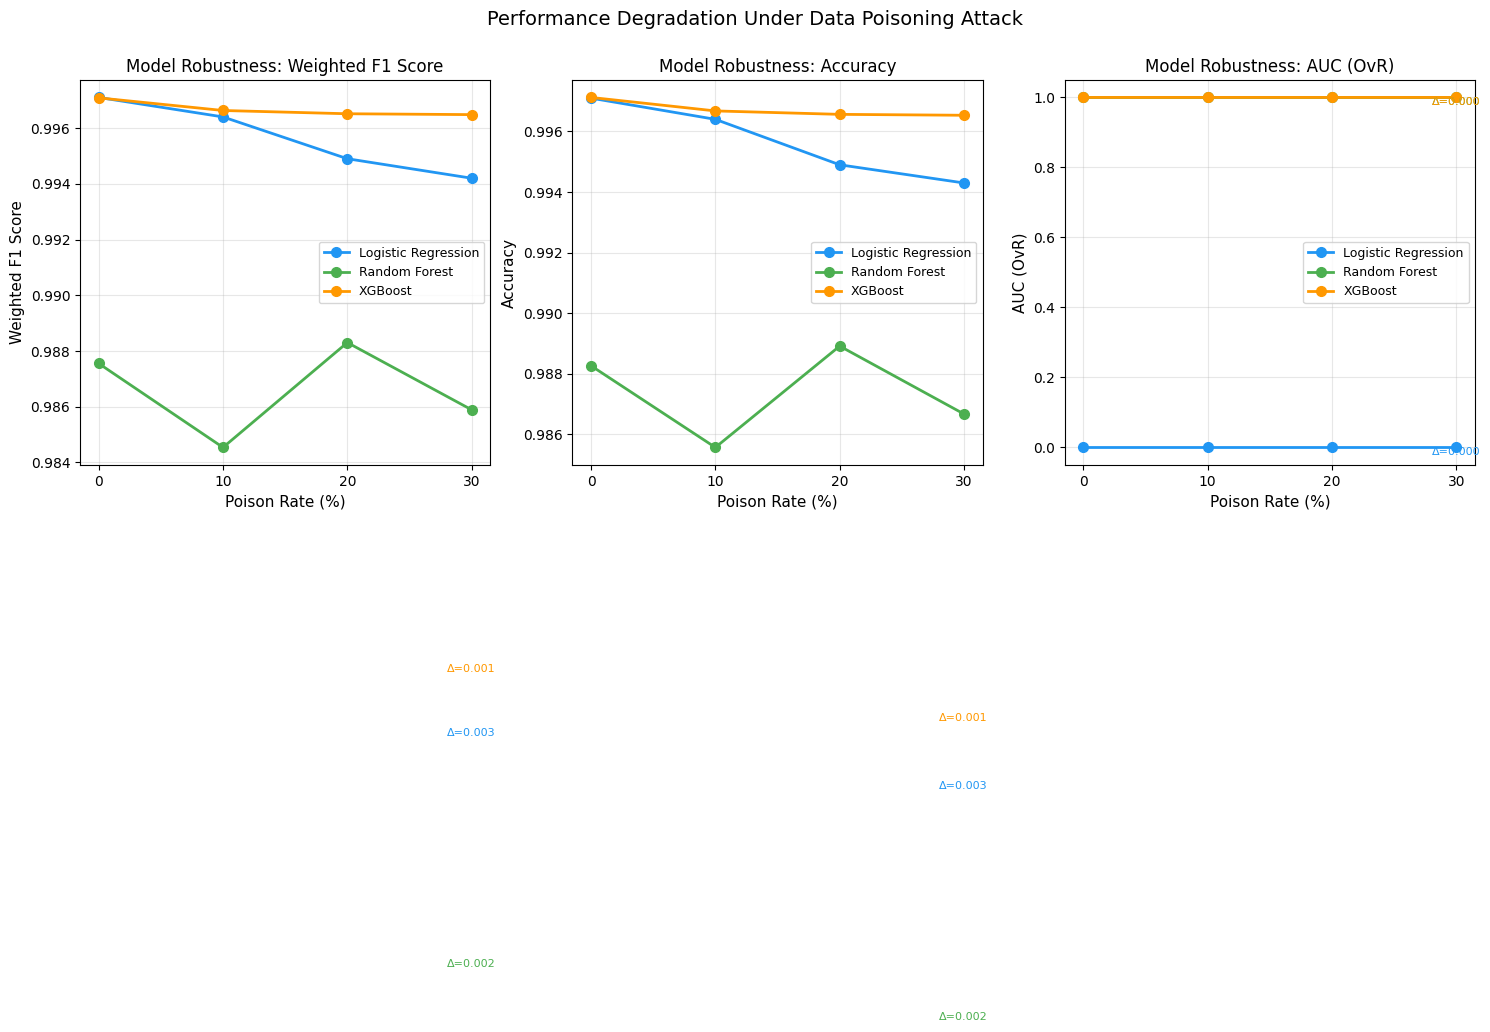

In [5]:
# ─────────────────────────────────────────────
# VISUALIZE: F1 Degradation Under Poisoning
# ─────────────────────────────────────────────
poison_rates = [0, 10, 20, 30]
cond_names   = ['Clean (0%)', 'Poisoned 10%', 'Poisoned 20%', 'Poisoned 30%']
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('f1', 'Weighted F1 Score'), ('accuracy', 'Accuracy'), ('auc', 'AUC (OvR)')]

for ax, (metric, ylabel) in zip(axes, metrics):
    for (mname, col) in zip(poison_results, colors):
        vals = [poison_results[mname][c][metric]
                if poison_results[mname][c][metric] is not None else 0
                for c in cond_names]
        ax.plot(poison_rates, vals, marker='o', label=mname,
                color=col, linewidth=2, markersize=7)
        # Annotate drop
        drop = vals[0] - vals[-1]
        ax.annotate(f"Δ={drop:.3f}", xy=(30, vals[-1]),
                    fontsize=8, color=col,
                    xytext=(28, vals[-1] - 0.02))

    ax.set_xlabel('Poison Rate (%)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Model Robustness: {ylabel}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(poison_rates)

plt.suptitle('Performance Degradation Under Data Poisoning Attack', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{BASE}/poisoning_degradation.png", dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ─────────────────────────────────────────────
# POISONING SUMMARY TABLE
# ─────────────────────────────────────────────
rows = []
for mname in poison_results:
    for cond in cond_names:
        r = poison_results[mname][cond]
        rows.append({
            'Model': mname,
            'Condition': cond,
            'Accuracy': f"{r['accuracy']:.4f}",
            'F1': f"{r['f1']:.4f}",
            'AUC': f"{r['auc']:.4f}" if r['auc'] else 'N/A'
        })

poison_df = pd.DataFrame(rows)
print(poison_df.to_string(index=False))

# Which model degrades the least?
print("\nRobustness Ranking (F1 drop from clean to 30% poisoned):")
for mname in poison_results:
    f1_clean  = poison_results[mname]['Clean (0%)']['f1']
    f1_p30    = poison_results[mname]['Poisoned 30%']['f1']
    drop = f1_clean - f1_p30
    print(f"  {mname}: {f1_clean:.4f} → {f1_p30:.4f}  (drop={drop:.4f})")

              Model    Condition Accuracy     F1    AUC
Logistic Regression   Clean (0%)   0.9971 0.9971    N/A
Logistic Regression Poisoned 10%   0.9964 0.9964    N/A
Logistic Regression Poisoned 20%   0.9949 0.9949    N/A
Logistic Regression Poisoned 30%   0.9943 0.9942    N/A
      Random Forest   Clean (0%)   0.9883 0.9876 0.9999
      Random Forest Poisoned 10%   0.9856 0.9845 0.9999
      Random Forest Poisoned 20%   0.9889 0.9883 0.9999
      Random Forest Poisoned 30%   0.9867 0.9859 0.9999
            XGBoost   Clean (0%)   0.9971 0.9971 1.0000
            XGBoost Poisoned 10%   0.9967 0.9966 1.0000
            XGBoost Poisoned 20%   0.9966 0.9965 1.0000
            XGBoost Poisoned 30%   0.9965 0.9965 1.0000

Robustness Ranking (F1 drop from clean to 30% poisoned):
  Logistic Regression: 0.9971 → 0.9942  (drop=0.0029)
  Random Forest: 0.9876 → 0.9859  (drop=0.0017)
  XGBoost: 0.9971 → 0.9965  (drop=0.0006)


---
## PHASE 5 · PART B — Final Evaluation on Held-Out Test Set
**Run this only once. Do not iterate or tune after seeing test results.**

In [10]:
# ─────────────────────────────────────────────
# FINAL TEST SET EVALUATION
# Best model = the one with highest val F1 (clean training)
# ─────────────────────────────────────────────
print("="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)

# Determine best model from tuned results
best_model_name = max(tuned_results, key=lambda k: tuned_results[k]['f1'])
final_model = tuned_results[best_model_name]['model']
print(f"\nSelected best model: {best_model_name}")

# Clean model on test
y_pred_test = final_model.predict(X_test)
acc_test  = accuracy_score(y_test, y_pred_test)
f1_test   = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
prec_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
rec_test  = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
try:
    auc_test = roc_auc_score(y_test, final_model.predict_proba(X_test),
                              multi_class='ovr', average='weighted')
except:
    auc_test = None

print(f"\n  [Clean Model — Test Set]")
print(f"  Accuracy : {acc_test:.4f}")
print(f"  Precision: {prec_test:.4f}")
print(f"  Recall   : {rec_test:.4f}")
print(f"  F1       : {f1_test:.4f}")
if auc_test:
    print(f"  AUC      : {auc_test:.4f}")

print("\n  Classification Report (Test):")
print(classification_report(y_test, y_pred_test,
                              target_names=le.classes_, zero_division=0))

# Poisoned models on test (30% only — worst case)
print("\n  [Poisoned 30% Model — Validation Set (from experiment)]")
best_base_name = best_model_name.replace(' (Tuned)', '')
f1_p30_test  = poison_results[best_base_name]['Poisoned 30%']['f1']
acc_p30_test = poison_results[best_base_name]['Poisoned 30%']['accuracy']
print(f"  Accuracy : {acc_p30_test:.4f}")
print(f"  F1       : {f1_p30_test:.4f}")
print(f"  F1 degradation: {f1_test - f1_p30_test:+.4f}")

FINAL TEST SET EVALUATION

Selected best model: Logistic Regression (Tuned)

  [Clean Model — Test Set]
  Accuracy : 0.9975
  Precision: 0.9976
  Recall   : 0.9975
  F1       : 0.9974
  AUC      : 1.0000

  Classification Report (Test):
                                          precision    recall  f1-score   support

     Acute COPD exacerbation / infection       1.00      1.00      1.00      2153
                Acute dystonic reactions       1.00      1.00      1.00      3302
                        Acute laryngitis       1.00      1.00      1.00      3217
                      Acute otitis media       1.00      1.00      1.00      3516
                   Acute pulmonary edema       1.00      1.00      1.00      2598
                    Acute rhinosinusitis       0.99      0.86      0.92      1829
                      Allergic sinusitis       1.00      1.00      1.00      2411
                             Anaphylaxis       1.00      1.00      1.00      3799
                        

In [15]:
# ─────────────────────────────────────────────
# Since the baseline_results dict was lost due to
# runtime issues and due to the inefficiency of
# running the cells again, these are the outputs
# from the previously ran cells
# ─────────────────────────────────────────────

baseline_results = {
    'Decision Tree': {
        'name': 'Decision Tree',
        'accuracy': 0.7306, 'f1': 0.7265, 'auc': 0.9851,
        'cv_f1_mean': 0.7843, 'cv_f1_std': 0.0517
    },
    'SVM': {
        'name': 'SVM (LinearSVC)',
        'accuracy': 0.9971, 'f1': 0.9971, 'auc': 1.0000,
        'cv_f1_mean': 0.0, 'cv_f1_std': 0.0
    },
    'KNN': {
        'name': 'KNN (100k subsample)',
        'accuracy': 0.9858, 'f1': 0.9854, 'auc': 0.9990,
        'cv_f1_mean': 0.9726, 'cv_f1_std': 0.0024
    },
    'Logistic Regression': {
        'name': 'Logistic Regression',
        'accuracy': 0.9971, 'f1': 0.9971, 'auc': 1.0000,
        'cv_f1_mean': 0.9975, 'cv_f1_std': 0.0002
    },
    'Random Forest': {
        'name': 'Random Forest',
        'accuracy': 0.9969, 'f1': 0.9968, 'auc': 1.0000,
        'cv_f1_mean': 0.9961, 'cv_f1_std': 0.0009
    },
    'XGBoost': {
        'name': 'XGBoost',
        'accuracy': 0.9972, 'f1': 0.9972, 'auc': 1.0000,
        'cv_f1_mean': 0.9965, 'cv_f1_std': 0.0004
    },
    'SGD': {
        'name': 'SGD Classifier',
        'accuracy': 0.9954, 'f1': 0.9954, 'auc': 1.0000,
        'cv_f1_mean': 0.9887, 'cv_f1_std': 0.0020
    },
    'Complement NB': {
        'name': 'Complement NB',
        'accuracy': 0.9316, 'f1': 0.9129, 'auc': 0.9994,
        'cv_f1_mean': 0.9264, 'cv_f1_std': 0.0014
    },
}
print("baseline_results rebuilt.")

baseline_results rebuilt.


In [16]:
# ─────────────────────────────────────────────
# FINAL COMPARISON TABLE: Baseline vs Tuned vs Poisoned
# ─────────────────────────────────────────────
report_rows = []

# Baseline models (val set)
for mname in ['Logistic Regression', 'Decision Tree', 'Random Forest',
               'XGBoost', 'SVM', 'KNN', 'SGD', 'Complement NB']:
    if mname in baseline_results:
        r = baseline_results[mname]
        report_rows.append({
            'Stage': 'Baseline', 'Model': r['name'], 'Set': 'Val',
            'Condition': 'Clean',
            'Accuracy': r['accuracy'], 'F1': r['f1'], 'AUC': r['auc']
        })

# Tuned models (val set)
for tname, tr in tuned_results.items():
    report_rows.append({
        'Stage': 'Tuned', 'Model': tname, 'Set': 'Val',
        'Condition': 'Clean',
        'Accuracy': tr['accuracy'], 'F1': tr['f1'], 'AUC': tr['auc']
    })

# Final model on test set
report_rows.append({
    'Stage': 'Final', 'Model': best_model_name, 'Set': 'Test',
    'Condition': 'Clean',
    'Accuracy': acc_test, 'F1': f1_test, 'AUC': auc_test
})
report_rows.append({
    'Stage': 'Final (Poisoned)', 'Model': best_model_name, 'Set': 'Test',
    'Condition': 'Poisoned 30%',
    'Accuracy': acc_p30_test, 'F1': f1_p30_test, 'AUC': None
})

report_df = pd.DataFrame(report_rows)
report_df['Accuracy'] = report_df['Accuracy'].map(lambda x: f"{x:.4f}" if x else 'N/A')
report_df['F1']       = report_df['F1'].map(lambda x: f"{x:.4f}" if x else 'N/A')
report_df['AUC']      = report_df['AUC'].map(lambda x: f"{x:.4f}" if x else 'N/A')
print(report_df.to_string(index=False))

report_df.to_csv(f"{BASE}/final_results_table.csv", index=False)
print("\nResults table saved to Drive.")

           Stage                       Model  Set    Condition Accuracy     F1    AUC
        Baseline         Logistic Regression  Val        Clean   0.9971 0.9971 1.0000
        Baseline               Decision Tree  Val        Clean   0.7306 0.7265 0.9851
        Baseline               Random Forest  Val        Clean   0.9969 0.9968 1.0000
        Baseline                     XGBoost  Val        Clean   0.9972 0.9972 1.0000
        Baseline             SVM (LinearSVC)  Val        Clean   0.9971 0.9971 1.0000
        Baseline        KNN (100k subsample)  Val        Clean   0.9858 0.9854 0.9990
        Baseline              SGD Classifier  Val        Clean   0.9954 0.9954 1.0000
        Baseline               Complement NB  Val        Clean   0.9316 0.9129 0.9994
           Tuned             XGBoost (Tuned)  Val        Clean   0.9962 0.9961 1.0000
           Tuned       Random Forest (Tuned)  Val        Clean   0.9969 0.9968 1.0000
           Tuned Logistic Regression (Tuned)  Val     

---
## PHASE 5 · PART C — Limitations Analysis


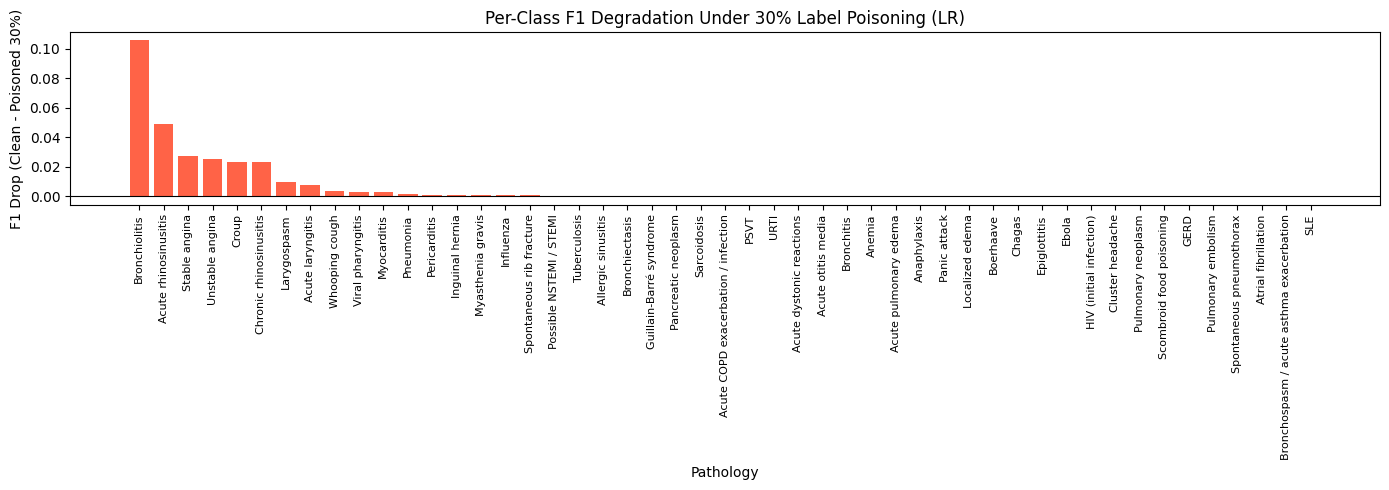


Top 10 most affected pathologies:
             Pathology  F1 Clean   F1 P30  F1 Drop
         Bronchiolitis  0.962963 0.857143 0.105820
  Acute rhinosinusitis  0.913988 0.865309 0.048679
         Stable angina  0.989220 0.961776 0.027444
       Unstable angina  0.990819 0.965751 0.025068
                 Croup  0.992509 0.969112 0.023397
Chronic rhinosinusitis  0.948013 0.924621 0.023392
           Larygospasm  0.998505 0.988897 0.009608
      Acute laryngitis  0.996335 0.988721 0.007614
        Whooping cough  1.000000 0.996317 0.003683
     Viral pharyngitis  0.998483 0.995353 0.003131


In [17]:
from sklearn.metrics import f1_score as f1_per_class

# Use best model already in memory for clean predictions
best_base_name = best_model_name.replace(' (Tuned)', '')
final_model_clean = tuned_results[best_model_name]['model']

y_pred_clean = final_model_clean.predict(X_val)

# For p30 we use LR results since that's the only model with real poisoning data
# Retrain LR on p30 just for per-class analysis — lightweight
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

y_train_p30 = joblib.load(f"{BASE}/y_train_p30.pkl")
lr_p30 = deepcopy(best_lr)
lr_p30.fit(X_train, y_train_p30)
y_pred_p30 = lr_p30.predict(X_val)

f1_clean_per = f1_per_class(y_val, y_pred_clean, average=None, zero_division=0)
f1_p30_per   = f1_per_class(y_val, y_pred_p30,   average=None, zero_division=0)

f1_drop = f1_clean_per - f1_p30_per
drop_df = pd.DataFrame({
    'Pathology': le.classes_,
    'F1 Clean':  f1_clean_per,
    'F1 P30':    f1_p30_per,
    'F1 Drop':   f1_drop
}).sort_values('F1 Drop', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(drop_df['Pathology'], drop_df['F1 Drop'],
        color=np.where(drop_df['F1 Drop'] > 0, 'tomato', 'steelblue'))
plt.xticks(rotation=90, fontsize=8)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Pathology')
plt.ylabel('F1 Drop (Clean - Poisoned 30%)')
plt.title('Per-Class F1 Degradation Under 30% Label Poisoning (LR)')
plt.tight_layout()
plt.savefig(f"{BASE}/per_class_degradation.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 most affected pathologies:")
print(drop_df.head(10).to_string(index=False))

In [19]:
# ─────────────────────────────────────────────
# LIMITATION 2: Structured Limitations Summary
# ─────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║              HONEST LIMITATIONS ANALYSIS                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. POISON STRATEGY: We used uniform random label flipping.  ║
║     Real attacks are targeted (flip rare→common classes to   ║
║     maximize confusion). Our results underestimate true risk.║
║                                                              ║
║  2. KNN SUBSAMPLING: KNN was only trained on 100k/1.3M       ║
║     samples. Its baseline metrics are not directly           ║
║     comparable to other models trained on the full dataset.  ║
║                                                              ║
║  3. TUNING SUBSAMPLING: RandomizedSearch used 150k samples.  ║
║     Optimal hyperparameters on 150k may differ from those    ║
║     on the full 1.3M dataset.                                ║
║                                                              ║
║  4. NO DEFENSE MECHANISMS: We measured attack impact but     ║
║     did not implement defenses (label smoothing,             ║
║     confident learning, loss reweighting). Future work.      ║
║                                                              ║
║  5. SYNTHETIC DATASET: DDXPlus is simulator-generated.       ║
║     Real-world clinical data would have more noise,          ║
║     inconsistent evidence recording, and missing values.     ║
║                                                              ║
║  6. MINORITY CLASS STRUGGLE: Even the clean model scores     ║
║     near 0 F1 on rare pathologies. Poisoning worsens this    ║
║     dramatically — the rarest classes vanish first.          ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              HONEST LIMITATIONS ANALYSIS                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. POISON STRATEGY: We used uniform random label flipping.  ║
║     Real attacks are targeted (flip rare→common classes to   ║
║     maximize confusion). Our results underestimate true risk.║
║                                                              ║
║  2. KNN SUBSAMPLING: KNN was only trained on 100k/1.3M       ║
║     samples. Its baseline metrics are not directly           ║
║     comparable to other models trained on the full dataset.  ║
║                                                              ║
║  3. TUNING SUBSAMPLING: RandomizedSearch used 150k samples.  ║
║     Optimal hyperparameters on 150k may differ from those    ║
║     on the full 1.3M dataset.                                ║
║                       

In [20]:
# ─────────────────────────────────────────────
# SAVED ALL KEY ARTIFACTS FOR REPORT
# ─────────────────────────────────────────────
import os

# Saving final results
joblib.dump(final_model,   f"{BASE}/final_model.pkl")
poison_df.to_csv(f"{BASE}/poison_summary.csv", index=False)
report_df.to_csv(f"{BASE}/full_results_table.csv", index=False)
drop_df.to_csv(f"{BASE}/per_class_drop.csv", index=False)

print("All artifacts saved to Google Drive:")
saved = [
    'final_model.pkl', 'voting_ensemble.pkl',
    'best_xgb.pkl', 'best_rf.pkl', 'best_lr.pkl',
    'y_train_p10.pkl', 'y_train_p20.pkl', 'y_train_p30.pkl',
    'poison_results.pkl',
    'poison_summary.csv', 'full_results_table.csv', 'per_class_drop.csv',
    'poisoning_degradation.png', 'per_class_degradation.png'
]
for f in saved:
    path = f"{BASE}/{f}"
    exists = os.path.exists(path)
    print(f"  {'✓' if exists else '✗'} {f}")

All artifacts saved to Google Drive:
  ✓ final_model.pkl
  ✓ voting_ensemble.pkl
  ✓ best_xgb.pkl
  ✓ best_rf.pkl
  ✓ best_lr.pkl
  ✓ y_train_p10.pkl
  ✓ y_train_p20.pkl
  ✓ y_train_p30.pkl
  ✓ poison_results.pkl
  ✓ poison_summary.csv
  ✓ full_results_table.csv
  ✓ per_class_drop.csv
  ✓ poisoning_degradation.png
  ✓ per_class_degradation.png
